# Perpendicularidade

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio e distância entre dois pontos), [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (ângulo reto, ângulos suplementares e opostos pelo vértice), [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (casos LAL e LLL, usados na demonstração da mediatriz) e [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (transversal cortando duas retas, postulado das paralelas e a ferramenta `cruzamento`).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir retas perpendiculares e reconhecer o ângulo reto como o caso particular em que os quatro ângulos formados por duas retas concorrentes são iguais.
- Enunciar e aplicar o postulado de existência e unicidade da perpendicular por um ponto, esteja o ponto sobre a reta ou fora dela.
- Calcular a projeção ortogonal de um ponto sobre uma reta e a distância de um ponto a uma reta, e explicar por que essa é a menor distância possível.
- Definir a mediatriz de um segmento e reconhecê-la como o lugar geométrico dos pontos equidistantes das extremidades.

**Tempo estimado:** 50 a 65 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0407a_perpendicularidade.ipynb)

## Qual é o caminho mais curto até o rio?

Imagine que você mora numa casa no campo, no ponto $P$ do primeiro desenho logo abaixo, perto de um rio de margem reta. Está um calor enorme e você quer chegar à água **o mais rápido possível**; qualquer ponto da margem serve. Para onde você caminha?

A resposta intuitiva é "em linha reta, até o ponto da margem mais perto de casa". Certo! Mas **qual** é esse ponto? Repare nos cinco caminhos do desenho: todos são retos, todos chegam ao rio, e só um deles é o mais curto. O que ele tem de especial é que chega à margem formando um **ângulo reto** com ela (o quadradinho verde). A pergunta que guia este notebook é:

> **por que o caminho mais curto de um ponto até uma reta é sempre o que forma um ângulo reto com ela?**

O ângulo reto também é o segredo de vários objetos do dia a dia que só funcionam se ele for **perfeito**: o **esquadro** de desenho técnico, a **quina** de uma folha de papel, o **prumo** do pedreiro (um peso pendurado num fio, que marca a vertical) e o **nível de bolha** (que marca a horizontal). Uma parede fora de prumo pode rachar; uma estante fora de esquadro balança. Neste notebook você vai:
- dar nome às retas que formam ângulo reto e conhecer o símbolo delas, o $\perp$;
- descobrir que, por um ponto qualquer, passa **uma única** perpendicular a uma reta dada;
- **demonstrar** que o caminho perpendicular é mesmo o mais curto, e usar isso para definir a distância de um ponto a uma reta;
- conhecer a **mediatriz**, a reta dos pontos que estão "em cima do muro" entre dois lugares.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida, as mesmas de 0406a_paralelismo
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def desenhar_reta(ax, ponto, inclinacao: float, cor: str = COR_SECUNDARIA, estilo: str = "-",
                  largura: float = 2.5, nome: str | None = None, posicao_nome=None) -> None:
    """Desenha a reta que passa por `ponto` com a inclinação dada (em graus). Uma reta é infinita:
    desenhamos um pedaço bem comprido e o próprio eixo corta o que sobra (por isso, chame
    `preparar_eixo` ANTES). O nome da reta (letra minúscula) vai em `posicao_nome`."""
    p = np.array(ponto, dtype=float)
    d = direcao(inclinacao)
    ax.plot(*zip(p - 100 * d, p + 100 * d), color=cor, lw=largura, linestyle=estilo)
    if nome and posicao_nome is not None:
        ax.text(*posicao_nome, nome, color=cor, fontsize=14, style="italic", fontweight="bold",
                ha="center", va="center")


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))

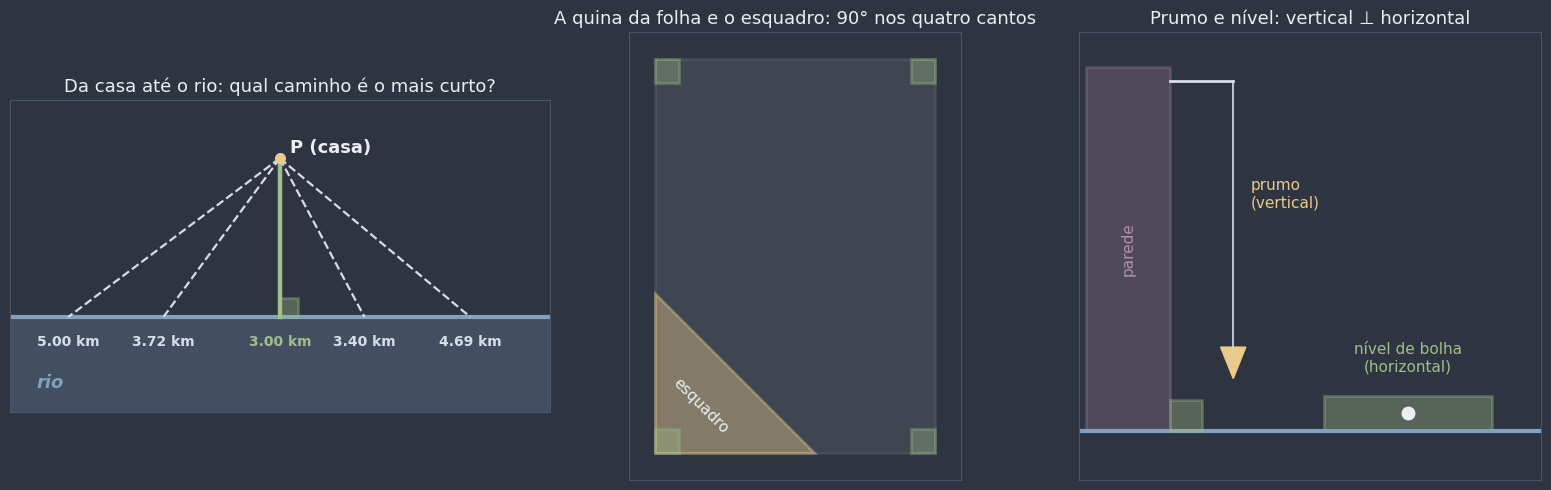

In [2]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(NORD_FUNDO)

# 1) A casa P e o rio: cinco caminhos retos até a margem, e só um é o mais curto
P = np.array([0.0, 3.0])
preparar_eixo(ax1, [(-5, -1.7), (5, 4.0)], margem=0.1)
ax1.add_patch(Polygon([(-6, 0), (6, 0), (6, -3), (-6, -3)], closed=True, facecolor=COR_SECUNDARIA, alpha=0.25,
                      edgecolor="none"))
ax1.plot([-6, 6], [0, 0], color=COR_SECUNDARIA, lw=3)
ax1.text(-4.6, -1.35, "rio", color=COR_SECUNDARIA, fontsize=13, style="italic", fontweight="bold")
for x in (-4.0, -2.2, 0.0, 1.6, 3.6):
    Q = np.array([x, 0.0])
    mais_curto = x == 0
    cor = COR_DESTAQUE if mais_curto else NORD_TEXTO_SEC
    ax1.plot(*zip(P, Q), color=cor, lw=3.2 if mais_curto else 1.6, linestyle="-" if mais_curto else "--")
    ax1.text(x, -0.55, f"{math.dist(P, Q):.2f} km", color=cor, fontsize=10, ha="center", fontweight="bold")
marcar_angulo_reto(ax1, (0, 0), (1, 0), P, tamanho=0.35)
desenhar_ponto(ax1, P, "P (casa)", deslocamento=(0.2, 0.1))
ax1.set_title("Da casa até o rio: qual caminho é o mais curto?", color=NORD_TEXTO, fontsize=13)

# 2) Uma folha de papel (proporção do A4) com um esquadro encaixado na quina
largura_folha, altura_folha = 5.25, 7.42
preparar_eixo(ax2, [(0, 0), (largura_folha, altura_folha)], margem=0.5)
cantos = [(0, 0), (largura_folha, 0), (largura_folha, altura_folha), (0, altura_folha)]
ax2.add_patch(Polygon(cantos, closed=True, facecolor=NORD_TEXTO_SEC, alpha=0.1, edgecolor=NORD_TEXTO_SEC, lw=2))
ax2.add_patch(Polygon([(0, 0), (3.0, 0), (0, 3.0)], closed=True, facecolor=COR_AVISO, alpha=0.4,
                      edgecolor=COR_AVISO, lw=2))
ax2.text(0.85, 0.9, "esquadro", color=NORD_TEXTO, fontsize=11, rotation=-45, ha="center", va="center")
for k, canto in enumerate(cantos):
    vizinho_1, vizinho_2 = cantos[(k + 1) % 4], cantos[(k - 1) % 4]
    marcar_angulo_reto(ax2, canto, vizinho_1, vizinho_2, tamanho=0.45)
ax2.set_title("A quina da folha e o esquadro: 90° nos quatro cantos", color=NORD_TEXTO, fontsize=13)

# 3) Prumo (marca a vertical) e nível de bolha (marca a horizontal)
preparar_eixo(ax3, [(-1.2, -0.6), (5.2, 5.6)], margem=0.1)
ax3.plot([-2, 7], [0, 0], color=COR_SECUNDARIA, lw=3)
ax3.add_patch(Polygon([(-1.2, 0), (0, 0), (0, 5.2), (-1.2, 5.2)], closed=True, facecolor=COR_EXTRA, alpha=0.25,
                      edgecolor=COR_EXTRA, lw=2))
ax3.text(-0.6, 2.6, "parede", color=COR_EXTRA, fontsize=11, rotation=90, ha="center", va="center")
ax3.plot([0, 0.9], [5.0, 5.0], color=NORD_TEXTO_SEC, lw=2)
ax3.plot([0.9, 0.9], [5.0, 1.2], color=NORD_TEXTO_SEC, lw=1.2)
ax3.add_patch(Polygon([(0.72, 1.2), (1.08, 1.2), (0.9, 0.75)], closed=True, facecolor=COR_AVISO, edgecolor=COR_AVISO))
ax3.text(1.15, 3.2, "prumo\n(vertical)", color=COR_AVISO, fontsize=11)
ax3.add_patch(Polygon([(2.2, 0.02), (4.6, 0.02), (4.6, 0.5), (2.2, 0.5)], closed=True, facecolor=COR_DESTAQUE,
                      alpha=0.35, edgecolor=COR_DESTAQUE, lw=2))
ax3.plot(3.4, 0.26, "o", color=NORD_TEXTO, markersize=9)
ax3.text(3.4, 0.85, "nível de bolha\n(horizontal)", color=COR_DESTAQUE, fontsize=11, ha="center")
marcar_angulo_reto(ax3, (0, 0), (1, 0), (0, 1), tamanho=0.45)
ax3.set_title("Prumo e nível: vertical ⊥ horizontal", color=NORD_TEXTO, fontsize=13)

plt.tight_layout()
plt.show()

Os três desenhos têm o mesmo ingrediente: o **ângulo reto**. Na seção 1 vamos dar nome às retas que se cruzam formando ângulo reto; na seção 2, ver que, por um ponto, só existe **uma** delas; na seção 3, provar que o caminho verde do rio é **mesmo** o mais curto; e, na seção 4, juntar perpendicular e ponto médio para construir a **mediatriz**.

## 1. Retas perpendiculares e ângulo reto

Em [`0403a_angulos.ipynb`](0403a_angulos.ipynb) você viu que duas retas **concorrentes** formam, no ponto em que se cruzam, quatro ângulos: dois pares de **opostos pelo vértice** (congruentes) e, lado a lado, ângulos **adjacentes suplementares** (que somam 180°, porque juntos formam um ângulo raso). Em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) esses quatro ângulos foram numerados de 1 a 4, começando pelo de cima à direita, no sentido anti-horário. Então, se o ângulo 1 mede $\alpha$, os quatro medem

$$\alpha, \qquad 180^\circ - \alpha, \qquad \alpha, \qquad 180^\circ - \alpha.$$

Existe um único valor de $\alpha$ que deixa os quatro ângulos **iguais**: $\alpha = 180^\circ - \alpha$, ou seja, $\alpha = 90^\circ$.

📌 **Definição formal (retas perpendiculares):** duas retas $r$ e $s$ são **perpendiculares** (notação $r \perp s$, que se lê "$r$ é perpendicular a $s$") quando são concorrentes e formam um **ângulo reto** no ponto de cruzamento. Como consequência, os **quatro** ângulos formados são retos.

Duas retas concorrentes que **não** são perpendiculares são chamadas **oblíquas**. E a relação é simétrica: se $r \perp s$, então $s \perp r$ (o ângulo reto é o mesmo, visto pelos dois lados).

Por que **um** ângulo reto já garante **quatro**? É uma demonstração curtinha, só com as ferramentas de 0403a:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | ângulo 1 = 90° | hipótese |
| 2 | ângulo 1 + ângulo 2 = 180° | adjacentes que formam um ângulo raso: suplementares (0403a) |
| 3 | ângulo 2 = 180° − 90° = 90° | passos 1 e 2 |
| 4 | ângulo 3 = ângulo 1 = 90° | opostos pelo vértice (0403a) |
| 5 | ângulo 4 = ângulo 2 = 90° | opostos pelo vértice (0403a) ∎ |

**No código**, continuamos descrevendo uma reta como em 0406a: por um **ponto** por onde ela passa e pela sua **inclinação**, o ângulo (em graus) que ela faz com a horizontal. O ângulo entre duas retas sai da **diferença** entre as inclinações, sempre "a menos de 180°" (inclinações de 30° e de 210° descrevem a mesma reta). Resultado: **$r \perp s$ quando as inclinações diferem de 90°**, a menos de 180°.

In [3]:
def angulos_do_cruzamento(inclinacao_r: float, inclinacao_s: float) -> list[float]:
    """Os quatro ângulos (1, 2, 3 e 4) formados por duas retas concorrentes com as inclinações dadas."""
    alfa = (inclinacao_s - inclinacao_r) % 180
    return [alfa, 180 - alfa, alfa, 180 - alfa]


def sao_perpendiculares(inclinacao_r: float, inclinacao_s: float) -> bool:
    """True se as retas com essas inclinações são perpendiculares (diferença de 90°, a menos de 180°)."""
    return math.isclose((inclinacao_s - inclinacao_r) % 180, 90, abs_tol=1e-9)


def classificar_cruzamento(inclinacao_r: float, inclinacao_s: float) -> str:
    """'perpendiculares', 'oblíquas' ou 'mesma direção (paralelas)'."""
    diferenca = (inclinacao_s - inclinacao_r) % 180
    if math.isclose(diferenca, 0, abs_tol=1e-9) or math.isclose(diferenca, 180, abs_tol=1e-9):
        return "mesma direção (paralelas)"
    return "perpendiculares" if sao_perpendiculares(inclinacao_r, inclinacao_s) else "oblíquas"


pares = [(0, 90), (0, 60), (30, 120), (30, -60), (150, 60), (45, 135), (10, 100.5), (20, 200)]
linhas = []
for incl_r, incl_s in pares:
    classificacao = classificar_cruzamento(incl_r, incl_s)
    angulos = ("—" if classificacao.startswith("mesma")
               else ", ".join(f"{a:g}°" for a in angulos_do_cruzamento(incl_r, incl_s)))
    linhas.append({
        "inclinação de r": f"{incl_r:g}°",
        "inclinação de s": f"{incl_s:g}°",
        "diferença (a menos de 180°)": f"{(incl_s - incl_r) % 180:g}°",
        "ângulos 1, 2, 3, 4": angulos,
        "classificação": classificacao,
        "r ⊥ s?": "✅" if sao_perpendiculares(incl_r, incl_s) else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

inclinação de r,inclinação de s,diferença (a menos de 180°),"ângulos 1, 2, 3, 4",classificação,r ⊥ s?
0°,90°,90°,"90°, 90°, 90°, 90°",perpendiculares,✅
0°,60°,60°,"60°, 120°, 60°, 120°",oblíquas,❌
30°,120°,90°,"90°, 90°, 90°, 90°",perpendiculares,✅
30°,-60°,90°,"90°, 90°, 90°, 90°",perpendiculares,✅
150°,60°,90°,"90°, 90°, 90°, 90°",perpendiculares,✅
45°,135°,90°,"90°, 90°, 90°, 90°",perpendiculares,✅
10°,100.5°,90.5°,"90.5°, 89.5°, 90.5°, 89.5°",oblíquas,❌
20°,200°,0°,—,mesma direção (paralelas),❌


Repare em três detalhes da tabela:
- **30° e −60°** são perpendiculares: a diferença é −90°, que "a menos de 180°" é o mesmo que 90°. Do mesmo jeito, **150° e 60°**.
- **10° e 100,5°** quase são, mas não são: os ângulos ficam com 90,5° e 89,5°. Perpendicularidade é uma condição **exata**.
- **20° e 200°** nem se cruzam num ponto só: têm a mesma direção.

Agora a representação gráfica. Nos três painéis, cada ângulo formado aparece pintado com a sua medida; quando as retas são perpendiculares, o arco vira o **quadradinho**, o símbolo do ângulo reto nos desenhos de geometria.

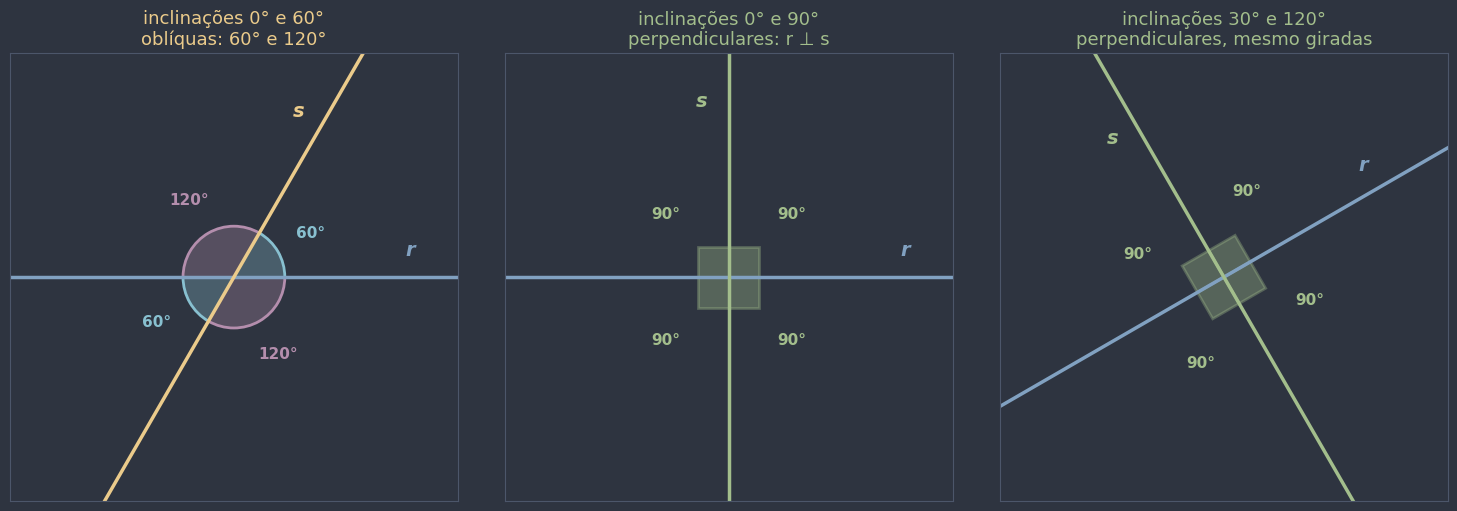

In [4]:
def desenhar_cruzamento(ax, X, inclinacao_r: float, inclinacao_s: float, raio: float = 0.8) -> None:
    """Pinta os quatro ângulos formados no cruzamento X das retas de inclinações dadas, com as medidas.
    Se as retas forem perpendiculares, os quatro ganham o quadradinho de ângulo reto, em verde."""
    alfa = (inclinacao_s - inclinacao_r) % 180
    inicios = [inclinacao_r, inclinacao_r + alfa, inclinacao_r + 180, inclinacao_r + 180 + alfa]
    aberturas = [alfa, 180 - alfa, alfa, 180 - alfa]
    retas_perpendiculares = sao_perpendiculares(inclinacao_r, inclinacao_s)
    for k, (inicio, abertura) in enumerate(zip(inicios, aberturas)):
        cor = COR_DESTAQUE if retas_perpendiculares else (COR_PONTO, COR_EXTRA)[k % 2]
        desenhar_setor(ax, X, inicio, abertura, raio=raio, cor=cor, rotulo=f"{abertura:.0f}°",
                       raio_rotulo=1.75 * raio)


def posicao_do_nome(X, inclinacao: float, distancia: float = 2.6):
    """Um bom lugar para escrever o nome de uma reta: longe do cruzamento X e um pouco ao lado dela."""
    return np.asarray(X, dtype=float) + distancia * direcao(inclinacao) + 0.4 * direcao(inclinacao + 90)


fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(NORD_FUNDO)
casos = [
    (0, 60, "oblíquas: 60° e 120°"),
    (0, 90, "perpendiculares: r ⊥ s"),
    (30, 120, "perpendiculares, mesmo giradas"),
]
for ax, (incl_r, incl_s, titulo) in zip(eixos, casos):
    preparar_eixo(ax, [(-3.3, -3.3), (3.3, 3.3)], margem=0)
    cor_s = COR_DESTAQUE if sao_perpendiculares(incl_r, incl_s) else COR_AVISO
    desenhar_reta(ax, (0, 0), incl_r, cor=COR_SECUNDARIA, nome="r", posicao_nome=posicao_do_nome((0, 0), incl_r))
    desenhar_reta(ax, (0, 0), incl_s, cor=cor_s, nome="s", posicao_nome=posicao_do_nome((0, 0), incl_s))
    desenhar_cruzamento(ax, (0, 0), incl_r, incl_s, raio=0.75)
    ax.set_title(f"inclinações {incl_r}° e {incl_s}°\n{titulo}", color=cor_s, fontsize=13)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** achar que é preciso conferir os **quatro** ângulos para concluir que duas retas são perpendiculares, ou, ao contrário, achar que um ângulo reto "sozinho" não basta. Basta **um**: a demonstração acima mostra que, pelas relações de suplementares e de opostos pelo vértice de 0403a, os outros três são automaticamente retos. É por isso que os desenhos marcam o quadradinho em **um** só dos cantos.

⚠️ **Erro comum:** achar que perpendicular quer dizer "uma reta deitada e outra em pé". No terceiro painel, nenhuma das duas retas é horizontal ou vertical, e elas são perpendiculares do mesmo jeito: o que importa é o **ângulo entre elas**, não a posição no papel.

🕹️ **Widget interativo:** o slider `ângulo` muda o ângulo entre $r$ e $s$, e o slider `giro` gira as duas retas juntas. Procure a posição em que as quatro medidas ficam iguais (o desenho muda de cor e o título avisa). Depois, com as retas perpendiculares, mexa só no `giro`: elas continuam perpendiculares em qualquer posição.

In [5]:
def explorar_perpendicular(angulo: int, giro: int) -> None:
    incl_r, incl_s = giro, giro + angulo
    fig, ax = plt.subplots(figsize=(8, 6.2))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-4, -3.1), (4, 3.1)], margem=0)
    perpendiculares = sao_perpendiculares(incl_r, incl_s)
    cor_s = COR_DESTAQUE if perpendiculares else COR_AVISO
    desenhar_reta(ax, (0, 0), incl_r, cor=COR_SECUNDARIA, nome="r", posicao_nome=posicao_do_nome((0, 0), incl_r, 2.5))
    desenhar_reta(ax, (0, 0), incl_s, cor=cor_s, nome="s", posicao_nome=posicao_do_nome((0, 0), incl_s, 2.5))
    desenhar_cruzamento(ax, (0, 0), incl_r, incl_s, raio=0.8)
    if perpendiculares:
        titulo = "ângulo de 90°: retas perpendiculares! (r ⊥ s) — os quatro ângulos são retos ✓"
    else:
        titulo = f"ângulos de {angulo}° e {180 - angulo}°: retas oblíquas (não são perpendiculares)"
    ax.set_title(titulo, color=cor_s, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_perpendicular,
    angulo=widgets.IntSlider(value=65, min=10, max=170, step=1, description="ângulo (°):"),
    giro=widgets.IntSlider(value=0, min=0, max=180, step=15, description="giro (°):"),
);

interactive(children=(IntSlider(value=65, description='ângulo (°):', max=170, min=10), IntSlider(value=0, desc…

🕵️ **Curiosidade histórica:** a palavra **perpendicular** vem do latim *perpendiculum*, que é justamente o **prumo**: o fio com um peso na ponta, que os construtores usam há milhares de anos para achar a vertical. Nos *Elementos*, Euclides define o ângulo reto e a perpendicular numa frase só (Livro I, Definição 10): quando uma reta, erguida sobre outra, forma com ela ângulos **adjacentes iguais**, cada um desses ângulos é **reto**, e a reta erguida é chamada **perpendicular** à outra. Repare que é a mesma ideia da nossa demonstração: ângulos adjacentes iguais e suplementares só podem medir 90°. Já o símbolo $\perp$ é bem mais recente: costuma ser atribuído ao matemático francês **Pierre Hérigone**, que o usou num livro de 1634.

🎯 **Aplicação prática — construção civil e desenho técnico:** o pedreiro confere a parede com o **prumo** (vertical) e o piso com o **nível** (horizontal); se os dois estiverem certos, parede e piso são perpendiculares. Os **esquadros** de desenho (e os de carpinteiro, de metal) são triângulos com um ângulo reto fabricado com precisão, usados para traçar perpendiculares e para conferir se uma quina está "no esquadro". Até a folha de papel sai da fábrica com quatro ângulos retos: é por isso que dá para usar a quina dela como um esquadro improvisado.

📖 **Leitura complementar:** [Perpendicularidade](https://pt.wikipedia.org/wiki/Perpendicularidade)

**Pergunta de checagem:** se duas retas concorrentes formam um ângulo de 90° de um lado, por que os outros três ângulos formados também são de 90°?

**Pergunta de checagem:** a reta $r$ tem inclinação de 25°. Quais inclinações $s$ pode ter para que $r \perp s$? (Dica: lembre que só importa a diferença "a menos de 180°".)

## 2. Existência e unicidade da perpendicular

Dados uma reta $r$ e um ponto $P$, quantas retas perpendiculares a $r$ passam por $P$? Há dois casos a olhar separadamente: $P$ **sobre** $r$ e $P$ **fora** de $r$.

📌 **Postulado (existência e unicidade da perpendicular):** por um ponto $P$ passa **uma única** reta perpendicular a uma reta $r$ dada, esteja $P$ sobre $r$ ou fora dela.

Neste curso aceitamos essa afirmação como postulado; alguns livros preferem demonstrá-la a partir de outros postulados. Ela é "irmã" do postulado das paralelas de [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb):

| | Postulado das paralelas (0406a) | Postulado da perpendicular |
|---|---|---|
| relação procurada | $s \parallel r$ | $s \perp r$ |
| $P$ fora de $r$ | uma **única** paralela | uma **única** perpendicular |
| $P$ sobre $r$ | uma única: a própria $r$ | uma **única** perpendicular |
| inclinação da reta procurada | a **mesma** de $r$ | a de $r$ **mais 90°** |

**No código**, isso vira uma receita: a perpendicular a $r$ por $P$ é a reta que passa por $P$ com a inclinação de $r$ mais 90°. E o ponto em que ela encontra $r$ (vamos chamá-lo de $P'$; ele ganha um nome próprio na seção 3) sai da função `cruzamento` de 0406a. Se $P$ já está sobre $r$, o cruzamento é o próprio $P$.

**A representação numérica.** Para ver a unicidade, vamos girar uma reta em torno de um ponto $P = (1, 3)$, fora de $r$ (que é o eixo horizontal), e medir, com o transferidor digital, o ângulo que ela forma com $r$ no ponto em que a cruza.

In [6]:
def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def pe_da_perpendicular(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Ponto em que a perpendicular a r (que passa por `ponto_r`) traçada por P encontra r.
    Se P estiver sobre r, devolve o próprio P."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


P = np.array([1.0, 3.0])
linhas = []
for inclinacao in [30, 60, 80, 89, 90, 91, 100, 120, 150]:
    X = cruzamento(P, inclinacao, (0, 0), 0)
    angulo = medir_angulo(X, X + direcao(0), P)  # entre r (para a direita) e a reta (subindo até P)
    linhas.append({
        "inclinação da reta por P": f"{inclinacao}°",
        "cruza r em": f"x = {X[0]:.3f}",
        "ângulos formados com r": f"{angulo:.0f}° e {180 - angulo:.0f}°",
        "perpendicular a r?": "✅" if math.isclose(angulo, 90) else "❌",
    })
print("r: eixo horizontal (inclinação 0°);  P = (1, 3), fora de r\n")
display(pd.DataFrame(linhas).style.hide(axis="index"))
print(f"Pela receita: inclinação da perpendicular = {inclinacao_da_perpendicular(0):g}°;  "
      f"ela encontra r em P' = {tuple(round(float(c), 3) for c in pe_da_perpendicular(P, (0, 0), 0))}")

r: eixo horizontal (inclinação 0°);  P = (1, 3), fora de r



inclinação da reta por P,cruza r em,ângulos formados com r,perpendicular a r?
30°,x = -4.196,30° e 150°,❌
60°,x = -0.732,60° e 120°,❌
80°,x = 0.471,80° e 100°,❌
89°,x = 0.948,89° e 91°,❌
90°,x = 1.000,90° e 90°,✅
91°,x = 1.052,91° e 89°,❌
100°,x = 1.529,100° e 80°,❌
120°,x = 2.732,120° e 60°,❌
150°,x = 6.196,150° e 30°,❌


Pela receita: inclinação da perpendicular = 90°;  ela encontra r em P' = (1.0, 0.0)


Só uma linha da tabela tem o ✅: a reta de inclinação 90°. Com 89° ou 91° os ângulos já são 89° e 91°, e qualquer outro giro também estraga o ângulo reto.

💡 **Dica — por que não poderia haver duas (com $P$ fora de $r$):** se houvesse duas perpendiculares a $r$ passando por $P$, encontrando $r$ em dois pontos diferentes $H_1$ e $H_2$, o triângulo $PH_1H_2$ teria **dois ângulos retos**, em $H_1$ e em $H_2$. Só esses dois já somariam 180°, sobrando 0° para o ângulo em $P$, o que é impossível pela soma dos ângulos internos demonstrada em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb). Ou seja, nesse caso a unicidade até pode ser **demonstrada**; o postulado garante, além disso, que a perpendicular **existe** e que também é única quando $P$ está sobre $r$.

Agora a representação gráfica dos dois casos:

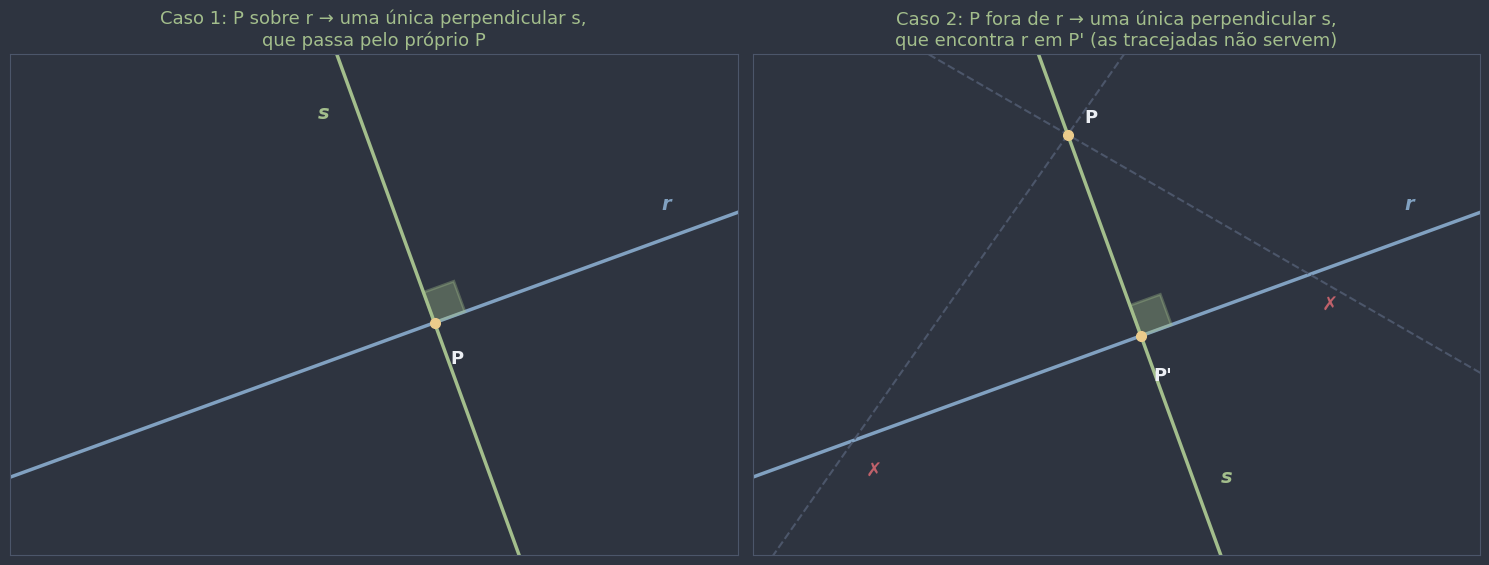

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.6))
fig.patch.set_facecolor(NORD_FUNDO)
incl_r = 20
quadro = [(-4.5, -2.6), (4.5, 3.6)]

# Caso 1: P sobre r
ax = ax1
preparar_eixo(ax, quadro, margem=0)
P = 0.8 * direcao(incl_r)
desenhar_reta(ax, (0, 0), incl_r, cor=COR_SECUNDARIA, nome="r", posicao_nome=posicao_do_nome((0, 0), incl_r, 4.0))
desenhar_reta(ax, P, inclinacao_da_perpendicular(incl_r), cor=COR_DESTAQUE, nome="s",
              posicao_nome=posicao_do_nome(P, inclinacao_da_perpendicular(incl_r), 2.9))
marcar_angulo_reto(ax, P, P + direcao(incl_r), P + direcao(incl_r + 90), tamanho=0.4)
desenhar_ponto(ax, P, "P", deslocamento=(0.2, -0.5))
ax.set_title("Caso 1: P sobre r → uma única perpendicular s,\nque passa pelo próprio P", color=COR_DESTAQUE,
             fontsize=13)

# Caso 2: P fora de r, com duas "tentativas" que não são perpendiculares
ax = ax2
preparar_eixo(ax, quadro, margem=0)
P = np.array([-0.6, 2.6])
desenhar_reta(ax, (0, 0), incl_r, cor=COR_SECUNDARIA, nome="r", posicao_nome=posicao_do_nome((0, 0), incl_r, 4.0))
for tentativa in (55, 150):
    desenhar_reta(ax, P, tentativa, cor=NORD_LINHA, estilo="--", largura=1.5)
    X = cruzamento(P, tentativa, (0, 0), incl_r)
    ax.text(X[0] + 0.15, X[1] - 0.45, "✗", color=COR_ALERTA, fontsize=14, fontweight="bold")
P_linha = pe_da_perpendicular(P, (0, 0), incl_r)
desenhar_reta(ax, P, inclinacao_da_perpendicular(incl_r), cor=COR_DESTAQUE, nome="s",
              posicao_nome=P_linha - 2.0 * direcao(inclinacao_da_perpendicular(incl_r)) + 0.4 * direcao(incl_r))
marcar_angulo_reto(ax, P_linha, P_linha + direcao(incl_r), P, tamanho=0.4)
desenhar_ponto(ax, P, "P", deslocamento=(0.2, 0.15))
desenhar_ponto(ax, P_linha, "P'", deslocamento=(0.15, -0.55))
ax.set_title("Caso 2: P fora de r → uma única perpendicular s,\nque encontra r em P' (as tracejadas não servem)",
             color=COR_DESTAQUE, fontsize=13)

plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** a reta $r$ passa pela origem; o slider `inclinação de r` gira a reta. O ponto $P$ é controlado por dois sliders: `ao longo de r` desliza $P$ na direção da reta, e `distância a r` afasta $P$ dela, para um lado (valores positivos) ou para o outro (negativos). A perpendicular verde é recalculada a cada movimento. Leve a `distância a r` até **0**: $P$ passa a estar **sobre** $r$ e a perpendicular continua existindo, e continua sendo uma só.

In [ ]:
def explorar_perpendicular_por_P(inclinacao_r: int, ao_longo: float, distancia: float) -> None:
    u, n = direcao(inclinacao_r), direcao(inclinacao_r + 90)
    P = ao_longo * u + distancia * n
    P_linha = pe_da_perpendicular(P, (0, 0), inclinacao_r)
    fig, ax = plt.subplots(figsize=(9, 6.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-5, -3.7), (5, 3.7)], margem=0)
    desenhar_reta(ax, (0, 0), inclinacao_r, cor=COR_SECUNDARIA, largura=3, nome="r",
                  posicao_nome=posicao_do_nome((0, 0), inclinacao_r, 4.3) if abs(inclinacao_r) < 40
                  else posicao_do_nome((0, 0), inclinacao_r, 3.2))
    desenhar_reta(ax, P, inclinacao_da_perpendicular(inclinacao_r), cor=COR_DESTAQUE, largura=2.5)
    lado = P if distancia != 0 else P_linha + n
    marcar_angulo_reto(ax, P_linha, P_linha + u, lado, tamanho=0.4)
    if distancia == 0:
        desenhar_ponto(ax, P, "P = P'", deslocamento=(0.25, -0.55))
        titulo = "P está SOBRE r: a única perpendicular a r por P passa pelo próprio P"
    else:
        desenhar_ponto(ax, P, "P", deslocamento=(0.2, 0.15))
        desenhar_ponto(ax, P_linha, "P'", cor=COR_DESTAQUE, deslocamento=(0.2, -0.55))
        titulo = (f"P fora de r: a única perpendicular a r por P encontra r em "
                  f"P' = ({P_linha[0]:.2f}, {P_linha[1]:.2f})")
    ax.set_title(titulo, color=COR_DESTAQUE, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_perpendicular_por_P,
    inclinacao_r=widgets.IntSlider(value=20, min=-60, max=60, step=5, description="inclinação de r:"),
    ao_longo=widgets.FloatSlider(value=-0.5, min=-3, max=3, step=0.5, description="ao longo de r:"),
    distancia=widgets.FloatSlider(value=2.5, min=-3, max=3, step=0.5, description="distância a r:"),
);

interactive(children=(IntSlider(value=20, description='inclinação de r:', max=60, min=-60, step=5), FloatSlide…

### Perpendiculares e paralelas juntas

Juntando este postulado com o que você viu em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) sobre uma transversal cortando duas retas, saem duas consequências muito usadas:

📌 **Consequência 1:** se $r \parallel s$ (distintas) e $t \perp r$, então $t \perp s$. Uma reta perpendicular a uma de duas paralelas é perpendicular à outra.

*Por quê?* $t$ corta $r$; então também corta $s$ (se não cortasse, $t$ e $r$ seriam duas paralelas a $s$ passando pelo mesmo ponto, contra o postulado das paralelas). Assim, $t$ é uma transversal a $r$ e $s$, e o ângulo de 90° que ela forma com $r$ tem um **correspondente** em $s$, que é congruente a ele, isto é, também mede 90°.

📌 **Consequência 2:** se $r \perp t$ e $s \perp t$ (com $r \neq s$), então $r \parallel s$. Duas retas perpendiculares a uma mesma reta são paralelas entre si.

*Por quê?* Agora $t$ é uma transversal a $r$ e $s$ formando dois ângulos **correspondentes** de 90°, que são congruentes. Pela recíproca de 0406a (o teste de paralelismo), $r \parallel s$.

🎯 **Aplicação prática — a escada de mão:** os dois montantes laterais de uma escada são paralelos, e os degraus são presos perpendicularmente a eles. Pela consequência 1, cada degrau perpendicular a um montante é perpendicular ao outro; pela consequência 2, todos os degraus são paralelos entre si (e o pé não escorrega de um degrau torto). Vamos conferir numa escada encostada na parede, com o transferidor digital.

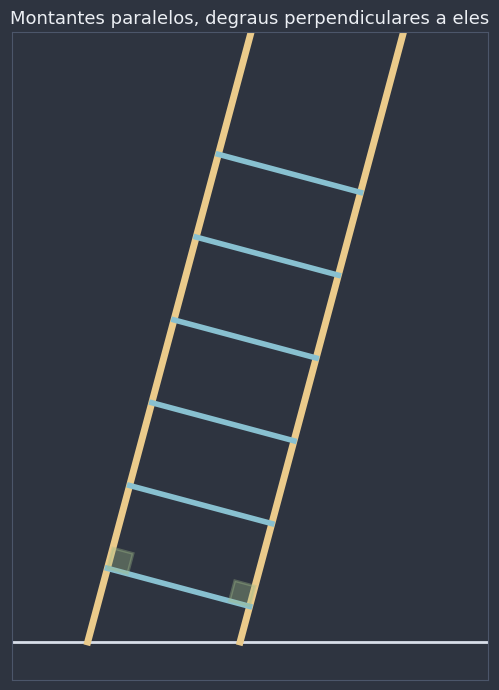

degrau,inclinação,ângulo com o montante esquerdo,ângulo com o montante direito
1,165°,90.0°,90.0°
2,165°,90.0°,90.0°
3,165°,90.0°,90.0°
4,165°,90.0°,90.0°
5,165°,90.0°,90.0°
6,165°,90.0°,90.0°


In [9]:
inclinacao_escada = 75                           # os montantes sobem a 75° do chão
inclinacao_degrau = inclinacao_da_perpendicular(inclinacao_escada)
montante_esq, montante_dir = np.array([0.0, 0.0]), np.array([1.6, 0.0])  # onde os montantes tocam o chão
# Os degraus partem do montante da esquerda, na direção perpendicular a ele
partidas = [montante_esq + k * direcao(inclinacao_escada) for k in np.arange(0.8, 6.0, 0.9)]

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.8, -0.4), (4.2, 6.4)], margem=0)
ax.plot([-2, 6], [0, 0], color=NORD_TEXTO_SEC, lw=2)
for base in (montante_esq, montante_dir):
    ax.plot(*zip(base, base + 7 * direcao(inclinacao_escada)), color=COR_AVISO, lw=5)
linhas = []
for numero, A in enumerate(partidas, start=1):
    B = cruzamento(A, inclinacao_degrau, montante_dir, inclinacao_escada)
    ax.plot(*zip(A, B), color=COR_PONTO, lw=4)
    linhas.append({
        "degrau": numero,
        "inclinação": f"{inclinacao_degrau:g}°",
        "ângulo com o montante esquerdo": f"{medir_angulo(A, A + direcao(inclinacao_escada), B):.1f}°",
        "ângulo com o montante direito": f"{medir_angulo(B, B + direcao(inclinacao_escada), A):.1f}°",
    })
A, B = partidas[0], cruzamento(partidas[0], inclinacao_degrau, montante_dir, inclinacao_escada)
marcar_angulo_reto(ax, A, A + direcao(inclinacao_escada), B, tamanho=0.22)
marcar_angulo_reto(ax, B, B + direcao(inclinacao_escada), A, tamanho=0.22)
ax.set_title("Montantes paralelos, degraus perpendiculares a eles", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()
display(pd.DataFrame(linhas).style.hide(axis="index"))

Todos os degraus têm a **mesma inclinação** (por isso são paralelos entre si) e formam 90° com os **dois** montantes, exatamente como as consequências 1 e 2 previam.

📎 **Conexão:** um caso particular deste postulado vai ser a estrela da seção 4: a perpendicular a um segmento traçada pelo seu **ponto médio** tem nome próprio, **mediatriz**.

**Pergunta de checagem:** quantas retas perpendiculares a $r$ existem passando por um ponto $P$ que não está em $r$? E se $P$ estiver em $r$?

**Pergunta de checagem:** num mesmo plano, duas retas diferentes, ambas perpendiculares a uma reta $t$, podem se cruzar? Por quê?

## 3. Projeção ortogonal e distância de ponto a reta

Imagine uma lanterna enorme, muito longe, cuja luz chega **perpendicularmente** à reta $r$. A "sombra" que um ponto $P$ projeta sobre $r$ é o ponto onde a perpendicular por $P$ encontra $r$, exatamente o $P'$ da seção 2.

📌 **Definição formal (projeção ortogonal):** a **projeção ortogonal** de um ponto $P$ sobre uma reta $r$ é o ponto $P'$ de $r$ tal que $\overline{PP'} \perp r$. Se $P$ está em $r$, a projeção é o próprio $P$. Pela seção 2, ela sempre **existe** e é **única**. ("Ortogonal" é outro nome para "perpendicular", muito usado quando se fala em projeções.)

📌 **Definição formal (distância de ponto a reta):** a **distância** de $P$ a $r$ é a medida do segmento $\overline{PP'}$, em que $P'$ é a projeção ortogonal de $P$ sobre $r$:

$$\operatorname{dist}(P, r) = PP'.$$

Se $P$ está em $r$, a distância é zero.

Por que usar **esse** segmento, e não outro qualquer de $P$ até $r$? Porque ele é o **mais curto** de todos: é o caminho verde do rio do gancho.

📌 **Teorema:** se $P'$ é a projeção ortogonal de $P$ sobre $r$ (com $P$ fora de $r$) e $Q$ é qualquer outro ponto de $r$, então $PP' < PQ$.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | o triângulo $PP'Q$ tem ângulo reto em $P'$ | $\overline{PP'} \perp r$ e $Q$ está em $r$ |
| 2 | o ângulo em $Q$ é agudo (menor que 90°) | um triângulo tem no máximo um ângulo reto ou obtuso (0404a) |
| 3 | o maior ângulo do triângulo é o de $P'$ | passos 1 e 2: o de $P$ também é agudo, pelo mesmo motivo |
| 4 | $PQ > PP'$ | ao maior ângulo opõe-se o maior lado (0404a): $\overline{PQ}$ é oposto ao ângulo reto ∎ |

Em outras palavras: no triângulo retângulo $PP'Q$, o segmento $\overline{PQ}$ é a **hipotenusa**, e a hipotenusa é sempre o maior lado.

**A representação numérica.** A reta $r$ passa pelos pontos $A = (-2, -1)$ e $B = (6, 3)$ (a inclinação dela sai de `direcao_de(A, B)`), e $P = (1, 5)$. Vamos calcular $P'$ e a distância, e depois comparar com a distância de $P$ a vários outros pontos $Q$ de $r$, obtidos andando a partir de $P'$ ao longo da reta.

In [10]:
def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r: o pé da perpendicular a r traçada por P."""
    return pe_da_perpendicular(P, ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


A, B = np.array([-2.0, -1.0]), np.array([6.0, 3.0])
inclinacao_AB = direcao_de(A, B)
P = np.array([1.0, 5.0])
P_linha = projecao_ortogonal(P, A, inclinacao_AB)
d = distancia_ponto_reta(P, A, inclinacao_AB)
print(f"inclinação de r = {inclinacao_AB:.2f}°")
print(f"P' = ({P_linha[0]:.2f}, {P_linha[1]:.2f})   (confira: o ângulo PP'B mede "
      f"{medir_angulo(P_linha, P, B):.1f}°)")
print(f"dist(P, r) = PP' = {d:.4f}\n")

linhas = []
for passo in [-4, -2, -1, -0.5, 0, 0.5, 1, 2, 4]:
    Q = P_linha + passo * direcao(inclinacao_AB)
    linhas.append({
        "Q = P' andando ao longo de r": f"{passo:+g}",
        "Q": f"({Q[0]:.2f}, {Q[1]:.2f})",
        "PQ": f"{math.dist(P, Q):.4f}",
        "mais curto?": "✅ (Q = P')" if passo == 0 else "",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

inclinação de r = 26.57°
P' = (2.80, 1.40)   (confira: o ângulo PP'B mede 90.0°)
dist(P, r) = PP' = 4.0249



Q = P' andando ao longo de r,Q,PQ,mais curto?
-4,"(-0.78, -0.39)",5.6745,
-2,"(1.01, 0.51)",4.4944,
-1,"(1.91, 0.95)",4.1473,
-0.5,"(2.35, 1.18)",4.0559,
+0,"(2.80, 1.40)",4.0249,✅ (Q = P')
+0.5,"(3.25, 1.62)",4.0559,
+1,"(3.69, 1.85)",4.1473,
+2,"(4.59, 2.29)",4.4944,
+4,"(6.38, 3.19)",5.6745,


A menor distância da tabela aparece exatamente quando $Q = P'$, e ela cresce para **os dois lados** à medida que $Q$ se afasta de $P'$ (de forma simétrica: andar 2 para um lado ou para o outro dá a mesma distância). Agora a figura: o segmento $\overline{PP'}$ em verde, com o ângulo reto, e alguns segmentos $\overline{PQ}$ tracejados, todos mais compridos.

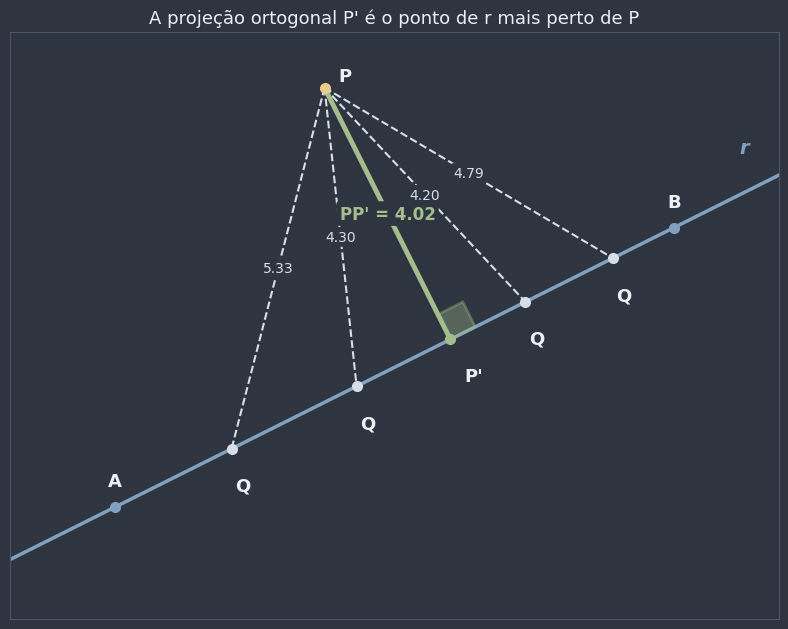

In [11]:
fig, ax = plt.subplots(figsize=(10, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-3.5, -2.6), (7.5, 5.8)], margem=0)
desenhar_reta(ax, A, inclinacao_AB, cor=COR_SECUNDARIA, nome="r", posicao_nome=(7.0, 4.15))
ROTULO = dict(boxstyle="round,pad=0.2", facecolor=NORD_FUNDO, edgecolor="none")  # fundo atrás do texto
for passo in (-3.5, -1.5, 1.2, 2.6):
    Q = P_linha + passo * direcao(inclinacao_AB)
    ax.plot(*zip(P, Q), color=NORD_TEXTO_SEC, lw=1.5, linestyle="--")
    meio = (P + Q) / 2
    ax.text(*meio, f"{math.dist(P, Q):.2f}", color=NORD_TEXTO_SEC, fontsize=10, ha="center", va="center",
            bbox=ROTULO)
    desenhar_ponto(ax, Q, "Q", cor=NORD_TEXTO_SEC, deslocamento=(0.05, -0.6))
ax.plot(*zip(P, P_linha), color=COR_DESTAQUE, lw=3.5)
meio = (P + P_linha) / 2
ax.text(*meio, f"PP' = {d:.2f}", color=COR_DESTAQUE, fontsize=12, fontweight="bold", ha="center", va="center",
        bbox=ROTULO)
marcar_angulo_reto(ax, P_linha, P_linha + direcao(inclinacao_AB), P, tamanho=0.4)
desenhar_ponto(ax, P, "P", deslocamento=(0.2, 0.1))
desenhar_ponto(ax, P_linha, "P'", cor=COR_DESTAQUE, deslocamento=(0.2, -0.6))
for X, nome in ((A, "A"), (B, "B")):
    desenhar_ponto(ax, X, nome, cor=COR_SECUNDARIA, deslocamento=(-0.1, 0.3))
ax.set_title("A projeção ortogonal P' é o ponto de r mais perto de P", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o slider `posição de Q` desliza o ponto $Q$ sobre $r$ (o 0 é o próprio $P'$). À esquerda, a figura; à direita, o **gráfico da distância** $PQ$ em função da posição de $Q$, com a posição atual marcada. Repare no formato da curva: ela tem um **ponto mais baixo**, um único, e ele fica exatamente na posição de $P'$.

In [12]:
def explorar_distancia(posicao: float) -> None:
    Q = P_linha + posicao * direcao(inclinacao_AB)
    distancia = math.dist(P, Q)
    no_minimo = math.isclose(posicao, 0)
    cor = COR_DESTAQUE if no_minimo else COR_ALERTA
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.6))
    fig.patch.set_facecolor(NORD_FUNDO)

    preparar_eixo(ax1, [(-4.5, -3.2), (8, 6)], margem=0)
    desenhar_reta(ax1, A, inclinacao_AB, cor=COR_SECUNDARIA, nome="r", posicao_nome=(7.5, 4.4))
    ax1.plot(*zip(P, P_linha), color=COR_DESTAQUE, lw=1.5, linestyle=":")
    marcar_angulo_reto(ax1, P_linha, P_linha + direcao(inclinacao_AB), P, tamanho=0.4)
    ax1.plot(*zip(P, Q), color=cor, lw=3)
    desenhar_ponto(ax1, P, "P", deslocamento=(0.2, 0.1))
    desenhar_ponto(ax1, P_linha, "P'", cor=COR_DESTAQUE, deslocamento=(-0.75, -0.2))
    desenhar_ponto(ax1, Q, "Q", cor=cor, deslocamento=(0.15, -0.65))
    ax1.set_title(f"PQ = {distancia:.3f}" + ("   (Q = P': a menor de todas ✓)" if no_minimo else ""),
                  color=cor, fontsize=13)

    estilizar_eixo(ax2)
    posicoes = np.linspace(-5, 5, 401)
    distancias = [math.dist(P, P_linha + k * direcao(inclinacao_AB)) for k in posicoes]
    ax2.plot(posicoes, distancias, color=COR_PONTO, lw=2.5)
    ax2.plot(0, d, "o", color=COR_DESTAQUE, markersize=10, label=f"mínimo: dist(P, r) = {d:.3f}")
    ax2.axvline(posicao, color=cor, lw=1.2, linestyle="--")
    ax2.plot(posicao, distancia, "o", color=cor, markersize=9)
    ax2.set_xlabel("posição de Q ao longo de r (0 = P')", color=NORD_TEXTO_SEC)
    ax2.set_ylabel("distância PQ", color=NORD_TEXTO_SEC)
    ax2.set_ylim(0, 8)
    ax2.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO)
    ax2.set_title("A distância PQ conforme Q se move", color=NORD_TEXTO, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_distancia,
    posicao=widgets.FloatSlider(value=2.5, min=-5, max=5, step=0.25, description="posição de Q:"),
);

interactive(children=(FloatSlider(value=2.5, description='posição de Q:', max=5.0, min=-5.0, step=0.25), Outpu…

🎯 **Aplicação prática — GPS e a rodovia mais próxima:** um aplicativo de mapas que precisa achar o ponto de uma estrada reta mais perto da sua posição faz, por trás, exatamente uma **projeção ortogonal**. Suponha que uma rodovia passe pelos pontos $(0, 2)$ e $(10, 7)$ de um mapa (em km) e que você esteja em $(3, 8)$:

In [13]:
entrada_1, entrada_2 = np.array([0.0, 2.0]), np.array([10.0, 7.0])  # dois pontos conhecidos da rodovia
voce = np.array([3.0, 8.0])
inclinacao_rodovia = direcao_de(entrada_1, entrada_2)
acesso = projecao_ortogonal(voce, entrada_1, inclinacao_rodovia)

print(f"Ponto da rodovia mais próximo de você: ({acesso[0]:.2f}, {acesso[1]:.2f})")
print(f"Distância até ele (em linha reta):     {math.dist(voce, acesso):.2f} km\n")
print("Para comparar, as distâncias até outros pontos da rodovia:")
for nome, ponto in [("(0, 2)", entrada_1), ("(10, 7)", entrada_2),
                    ("1 km depois do acesso", acesso + direcao(inclinacao_rodovia))]:
    print(f"  até {nome:<22}: {math.dist(voce, ponto):.2f} km")

Ponto da rodovia mais próximo de você: (4.80, 4.40)
Distância até ele (em linha reta):     4.02 km

Para comparar, as distâncias até outros pontos da rodovia:
  até (0, 2)                : 6.71 km
  até (10, 7)               : 7.07 km
  até 1 km depois do acesso : 4.15 km


🎯 **Aplicação prática — a largura de um rio:** a "largura" de um rio de margens retas e paralelas é medida **perpendicularmente** às margens. Uma consequência bonita das seções 2 e 3: se $r \parallel s$, então **todos** os pontos de $s$ estão à **mesma** distância de $r$. É a **distância entre as paralelas** (as setas dos trilhos no gancho de 0406a). Por isso dá para medir a largura de um rio a partir de um ponto **qualquer** de uma margem, sem precisar atravessá-lo para escolher "o ponto certo". Vamos conferir:

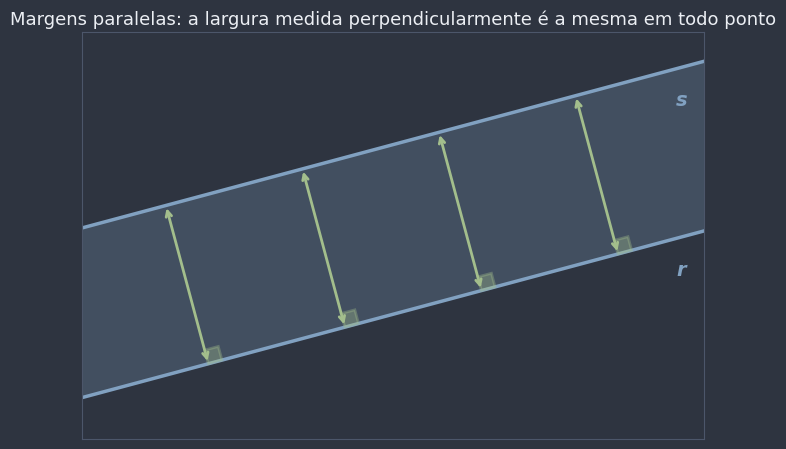

ponto X da margem s,"dist(X, r)"
"(0.48, 3.13)",2.8978
"(2.90, 3.78)",2.8978
"(5.31, 4.42)",2.8978
"(7.73, 5.07)",2.8978


In [14]:
inclinacao_margens = 15
margem_r, margem_s = np.array([0.0, 0.0]), np.array([0.0, 3.0])  # as duas margens têm a mesma inclinação
fig, ax = plt.subplots(figsize=(11, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-1, -1.0), (10, 6.2)], margem=0)
canto = [(-3, -3 * math.tan(math.radians(15))), (12, 12 * math.tan(math.radians(15)))]
ax.add_patch(Polygon([canto[0], canto[1], (canto[1][0], canto[1][1] + 3), (canto[0][0], canto[0][1] + 3)],
                     closed=True, facecolor=COR_SECUNDARIA, alpha=0.25, edgecolor="none"))
desenhar_reta(ax, margem_r, inclinacao_margens, cor=COR_SECUNDARIA, nome="r", posicao_nome=(9.6, 2.0))
desenhar_reta(ax, margem_s, inclinacao_margens, cor=COR_SECUNDARIA, nome="s", posicao_nome=(9.6, 5.0))
linhas = []
for passo in (0.5, 3.0, 5.5, 8.0):
    X = margem_s + passo * direcao(inclinacao_margens)
    X_linha = projecao_ortogonal(X, margem_r, inclinacao_margens)
    ax.annotate("", xy=X_linha, xytext=X, arrowprops=dict(arrowstyle="<->", color=COR_DESTAQUE, lw=2))
    marcar_angulo_reto(ax, X_linha, X_linha + direcao(inclinacao_margens), X, tamanho=0.25)
    linhas.append({"ponto X da margem s": f"({X[0]:.2f}, {X[1]:.2f})",
                   "dist(X, r)": f"{distancia_ponto_reta(X, margem_r, inclinacao_margens):.4f}"})
ax.set_title("Margens paralelas: a largura medida perpendicularmente é a mesma em todo ponto",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()
display(pd.DataFrame(linhas).style.hide(axis="index"))

💡 **Dica:** guarde bem a projeção ortogonal e a distância de ponto a reta. Elas voltam com força total em 📌 Triângulos Retângulos (a altura relativa à hipotenusa "projeta" os catetos sobre ela, e as relações métricas do triângulo retângulo são todas sobre essas projeções), e em Geometria Analítica, que tem uma fórmula pronta para a distância de um ponto a uma reta dada por equação.

📖 **Leitura complementar:** [Projeção ortogonal](https://pt.wikipedia.org/wiki/Proje%C3%A7%C3%A3o_ortogonal) (o verbete trata das projeções usadas em desenho técnico, que são a mesma ideia levada para o espaço)

**Pergunta de checagem:** por que a distância de um ponto a uma reta é definida usando especificamente a perpendicular, e não qualquer outro segmento até a reta?

**Pergunta de checagem:** se $P$ está sobre a reta $r$, quem é a projeção ortogonal de $P$ sobre $r$? E quanto vale $\operatorname{dist}(P, r)$?

## 4. Mediatriz de um segmento

Em [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) você conheceu o **ponto médio** $M$ de um segmento $\overline{AB}$, o único ponto do segmento que está à mesma distância de $A$ e de $B$. Agora juntamos ponto médio e perpendicular:

📌 **Definição formal (mediatriz):** a **mediatriz** de um segmento $\overline{AB}$ é a reta **perpendicular** a $\overline{AB}$ que passa pelo seu **ponto médio** $M$. Pelo postulado da seção 2, ela existe e é única.

📌 **Lugar geométrico:** um **lugar geométrico** (LG) é o conjunto de **todos** os pontos que satisfazem uma certa propriedade, e **só** deles. Para dizer que uma figura é o lugar geométrico de uma propriedade, é preciso mostrar duas coisas: (1) todo ponto da figura tem a propriedade; (2) todo ponto que tem a propriedade está na figura. A mediatriz é o primeiro exemplo de lugar geométrico do curso, e outros vêm por aí:

| Lugar geométrico | Propriedade dos pontos | Onde aparece |
|---|---|---|
| **mediatriz** de $\overline{AB}$ | equidistantes de $A$ e de $B$ | aqui |
| **bissetriz** de um ângulo | equidistantes dos dois lados do ângulo | [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) |
| **circunferência** de centro $O$ e raio $R$ | à distância $R$ de $O$ | 📌 Circunferência e Círculo |

📌 **Teorema (a mediatriz como lugar geométrico):** um ponto $P$ está na mediatriz de $\overline{AB}$ **se, e somente se,** $PA = PB$. Ou seja, a mediatriz é o lugar geométrico dos pontos **equidistantes** de $A$ e de $B$.

**Ida (todo ponto da mediatriz é equidistante):** seja $P$ um ponto da mediatriz, diferente de $M$ (se $P = M$, já sabemos que $MA = MB$).

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $AM = MB$ | $M$ é o ponto médio de $\overline{AB}$ |
| 2 | $P\hat{M}A = P\hat{M}B = 90^\circ$ | a mediatriz é perpendicular a $\overline{AB}$ |
| 3 | $PM = PM$ | lado comum |
| 4 | $\triangle PMA \equiv \triangle PMB$ | caso **LAL** (passos 1, 2 e 3), de 0405a |
| 5 | $PA = PB$ | lados correspondentes de triângulos congruentes ∎ |

**Volta (todo ponto equidistante está na mediatriz):** seja $P$ um ponto com $PA = PB$, fora da reta $\overleftrightarrow{AB}$ (sobre ela, o único ponto com $PA = PB$ é o próprio $M$).

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $PA = PB$, $AM = MB$ e $PM = PM$ | hipótese; ponto médio; lado comum |
| 2 | $\triangle PMA \equiv \triangle PMB$ | caso **LLL** (passo 1), de 0405a |
| 3 | $P\hat{M}A = P\hat{M}B$ | ângulos correspondentes |
| 4 | $P\hat{M}A + P\hat{M}B = 180^\circ$ | adjacentes que formam o ângulo raso $A\hat{M}B$ |
| 5 | $P\hat{M}A = 90^\circ$, isto é, $\overleftrightarrow{PM} \perp \overline{AB}$ | passos 3 e 4 |
| 6 | $P$ está na mediatriz | $\overleftrightarrow{PM}$ e a mediatriz são perpendiculares a $\overline{AB}$ por $M$: pela **unicidade** (seção 2), são a mesma reta ∎ |

Repare que o passo 6 só funciona por causa do postulado da seção 2: se pudesse haver duas perpendiculares por $M$, a reta $\overleftrightarrow{PM}$ poderia ser "a outra".

**No código**, a mediatriz é uma reta como as outras: passa pelo ponto médio $M$ e tem a inclinação de $\overline{AB}$ mais 90°. Vamos construí-la para $A = (1, 1)$ e $B = (7, 4)$ e medir $PA$ e $PB$ para vários pontos $P$ sobre ela, e também para alguns pontos fora dela.

In [15]:
def ponto_medio(A, B) -> np.ndarray:
    """Ponto médio do segmento AB (fórmula de 0402a)."""
    return (np.asarray(A, dtype=float) + np.asarray(B, dtype=float)) / 2


def mediatriz(A, B) -> tuple[np.ndarray, float]:
    """A mediatriz de AB, descrita como toda reta deste notebook: um ponto (o ponto médio M) e a inclinação."""
    return ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B))


A, B = np.array([1.0, 1.0]), np.array([7.0, 4.0])
M, inclinacao_m = mediatriz(A, B)
print(f"M = ({M[0]:g}, {M[1]:g});  inclinação de AB = {direcao_de(A, B):.2f}°;  "
      f"inclinação da mediatriz = {inclinacao_m:.2f}°\n")

linhas = []
for passo in [-4, -2.5, -1, 0, 1.5, 3, 5]:
    P = M + passo * direcao(inclinacao_m)
    linhas.append({"P (sobre a mediatriz)": f"({P[0]:.2f}, {P[1]:.2f})", "PA": f"{math.dist(P, A):.4f}",
                   "PB": f"{math.dist(P, B):.4f}", "PA = PB?": "✅" if math.isclose(math.dist(P, A), math.dist(P, B)) else "❌"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

linhas = []
for P in [np.array([2.0, 5.0]), np.array([6.0, 0.0]), np.array([4.0, 4.0]), np.array([7.0, 1.0])]:
    linhas.append({"P (fora da mediatriz)": f"({P[0]:g}, {P[1]:g})", "PA": f"{math.dist(P, A):.4f}",
                   "PB": f"{math.dist(P, B):.4f}",
                   "mais perto de": "A" if math.dist(P, A) < math.dist(P, B) else "B"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

M = (4, 2.5);  inclinação de AB = 26.57°;  inclinação da mediatriz = 116.57°



P (sobre a mediatriz),PA,PB,PA = PB?
"(5.79, -1.08)",5.2202,5.2202,✅
"(5.12, 0.26)",4.1833,4.1833,✅
"(4.45, 1.61)",3.5000,3.5000,✅
"(4.00, 2.50)",3.3541,3.3541,✅
"(3.33, 3.84)",3.6742,3.6742,✅
"(2.66, 5.18)",4.5000,4.5000,✅
"(1.76, 6.97)",6.0208,6.0208,✅


P (fora da mediatriz),PA,PB,mais perto de
"(2, 5)",4.1231,5.0990,A
"(6, 0)",5.0990,4.1231,B
"(4, 4)",4.2426,3.0000,B
"(7, 1)",6.0000,3.0000,B


Sobre a mediatriz, $PA$ e $PB$ coincidem até a última casa decimal; fora dela, nunca. E repare na última coluna: cada ponto fora da mediatriz fica **mais perto** de uma das extremidades. A mediatriz é a **fronteira** entre "mais perto de $A$" e "mais perto de $B$". Na figura, os tracinhos em $\overline{AM}$ e $\overline{MB}$ indicam segmentos congruentes (como em 0402a):

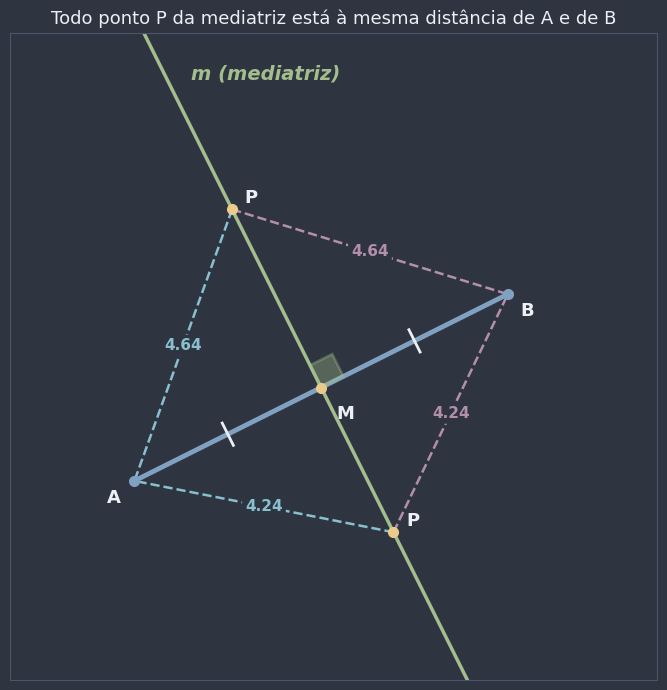

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-1, -2.2), (9.4, 8.2)], margem=0)
desenhar_reta(ax, M, inclinacao_m, cor=COR_DESTAQUE, nome="m (mediatriz)",
              posicao_nome=M + 4.9 * direcao(inclinacao_m) + 1.45 * direcao(inclinacao_m - 90))
ax.plot(*zip(A, B), color=COR_SECUNDARIA, lw=3.5)
marcar_angulo_reto(ax, M, B, M + direcao(inclinacao_m), tamanho=0.4)
# Tracinhos de congruência no meio de AM e de MB
normal = direcao(inclinacao_m)
for meio in (ponto_medio(A, M), ponto_medio(M, B)):
    ax.plot(*zip(meio - 0.2 * normal, meio + 0.2 * normal), color=NORD_TEXTO, lw=2)
for passo, cor_a, cor_b in [(3.2, COR_PONTO, COR_EXTRA), (-2.6, COR_PONTO, COR_EXTRA)]:
    P = M + passo * direcao(inclinacao_m)
    for X, cor in ((A, cor_a), (B, cor_b)):
        ax.plot(*zip(P, X), color=cor, lw=1.8, linestyle="--")
        meio = (P + X) / 2
        ax.text(*meio, f"{math.dist(P, X):.2f}", color=cor, fontsize=11, ha="center", va="center",
                fontweight="bold", bbox=dict(boxstyle="round,pad=0.2", facecolor=NORD_FUNDO, edgecolor="none"))
    desenhar_ponto(ax, P, "P", deslocamento=(0.2, 0.1))
desenhar_ponto(ax, A, "A", cor=COR_SECUNDARIA, deslocamento=(-0.45, -0.35))
desenhar_ponto(ax, B, "B", cor=COR_SECUNDARIA, deslocamento=(0.2, -0.35))
desenhar_ponto(ax, M, "M", deslocamento=(0.25, -0.5))
ax.set_title("Todo ponto P da mediatriz está à mesma distância de A e de B", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** agora $P$ anda livre pelo plano, com os sliders `x de P` e `y de P`. O fundo está pintado em duas cores: a região dos pontos **mais perto de $A$** (azul) e a dos pontos **mais perto de $B$** (lilás); a mediatriz, em verde, é a fronteira entre elas. O título mostra $PA$ e $PB$ em tempo real. Tente colocar $P$ **exatamente** em cima da mediatriz (dica: ela passa pela origem, por $(-0{,}5;\ 1)$ e por $(1;\ -2)$).

In [ ]:
A_w, B_w = np.array([-2.0, -1.0]), np.array([2.0, 1.0])
M_w, inclinacao_w = mediatriz(A_w, B_w)


def explorar_mediatriz(x_P: float, y_P: float) -> None:
    P = np.array([x_P, y_P])
    PA, PB = math.dist(P, A_w), math.dist(P, B_w)
    fig, ax = plt.subplots(figsize=(8.5, 8))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-4.5, -4.5), (4.5, 4.5)], margem=0)
    # As duas regiões: o semiplano do lado de A e o do lado de B, separados pela mediatriz
    u, para_B = direcao(inclinacao_w), direcao(direcao_de(A_w, B_w))
    for lado, cor in ((-1, COR_PONTO), (1, COR_EXTRA)):
        regiao = [M_w - 20 * u, M_w + 20 * u, M_w + 20 * u + lado * 20 * para_B, M_w - 20 * u + lado * 20 * para_B]
        ax.add_patch(Polygon(regiao, closed=True, facecolor=cor, alpha=0.12, edgecolor="none"))
    desenhar_reta(ax, M_w, inclinacao_w, cor=COR_DESTAQUE, largura=2.5)
    ax.plot(*zip(A_w, B_w), color=COR_SECUNDARIA, lw=3)
    marcar_angulo_reto(ax, M_w, B_w, M_w + u, tamanho=0.35)
    ax.plot(*zip(P, A_w), color=COR_PONTO, lw=1.8, linestyle="--")
    ax.plot(*zip(P, B_w), color=COR_EXTRA, lw=1.8, linestyle="--")
    desenhar_ponto(ax, A_w, "A", cor=COR_PONTO, deslocamento=(-0.45, -0.4))
    desenhar_ponto(ax, B_w, "B", cor=COR_EXTRA, deslocamento=(0.2, -0.4))
    desenhar_ponto(ax, P, "P", cor=NORD_TEXTO, deslocamento=(0.2, 0.15))
    if math.isclose(PA, PB):
        titulo, cor = f"PA = PB = {PA:.3f}: P está NA MEDIATRIZ ✓", COR_DESTAQUE
    else:
        mais_perto = "A" if PA < PB else "B"
        titulo, cor = f"PA = {PA:.3f}  e  PB = {PB:.3f}: P está mais perto de {mais_perto}", NORD_TEXTO
    ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_mediatriz,
    x_P=widgets.FloatSlider(value=-1.5, min=-4, max=4, step=0.5, description="x de P:"),
    y_P=widgets.FloatSlider(value=2.5, min=-4, max=4, step=0.5, description="y de P:"),
);

interactive(children=(FloatSlider(value=-1.5, description='x de P:', max=4.0, min=-4.0, step=0.5), FloatSlider…

🎯 **Aplicação prática — um posto de atendimento justo:** duas cidades, $A$ e $B$, querem dividir um posto de saúde, e a regra é que ele fique à **mesma distância** das duas. Qualquer ponto da mediatriz de $\overline{AB}$ resolve! Mas há uma exigência a mais: o posto precisa ficar **à beira de uma rodovia** que passa por ali. Então o lugar certo é o **cruzamento** da mediatriz com a rodovia, e a função `cruzamento` encontra esse ponto.

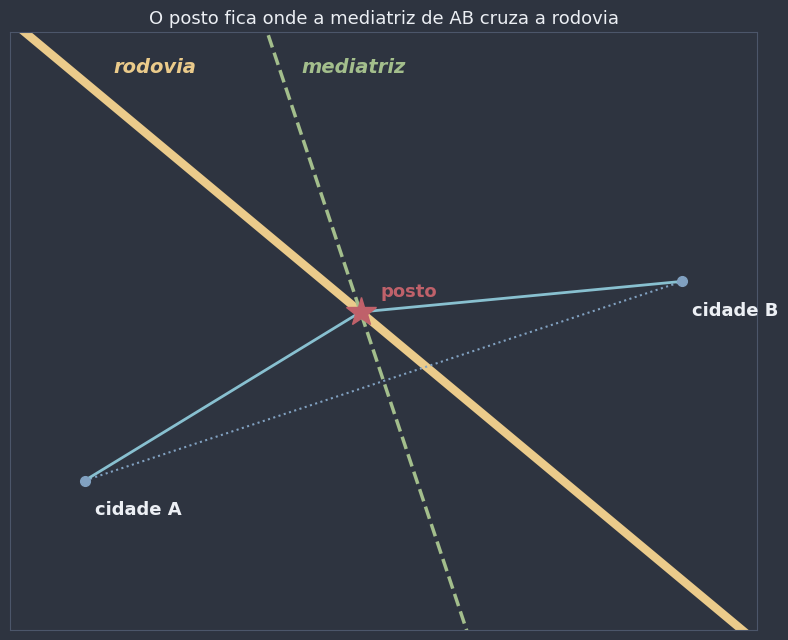

Posto em (5.54, 3.38)
  distância até a cidade A: 6.491 km
  distância até a cidade B: 6.491 km


In [18]:
cidade_A, cidade_B = np.array([0.0, 0.0]), np.array([12.0, 4.0])      # coordenadas em km
rodovia_1, rodovia_2 = np.array([0.0, 8.0]), np.array([12.0, -2.0])   # dois pontos da rodovia
M_cidades, inclinacao_med = mediatriz(cidade_A, cidade_B)
inclinacao_rodovia = direcao_de(rodovia_1, rodovia_2)
posto = cruzamento(M_cidades, inclinacao_med, rodovia_1, inclinacao_rodovia)

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-1.5, -3), (13.5, 9)], margem=0)
desenhar_reta(ax, rodovia_1, inclinacao_rodovia, cor=COR_AVISO, largura=6, nome="rodovia", posicao_nome=(1.4, 8.3))
desenhar_reta(ax, M_cidades, inclinacao_med, cor=COR_DESTAQUE, estilo="--", nome="mediatriz",
              posicao_nome=(5.4, 8.3))
ax.plot(*zip(cidade_A, cidade_B), color=COR_SECUNDARIA, lw=1.5, linestyle=":")
for cidade, nome in ((cidade_A, "cidade A"), (cidade_B, "cidade B")):
    ax.plot(*zip(posto, cidade), color=COR_PONTO, lw=2)
    desenhar_ponto(ax, cidade, nome, cor=COR_SECUNDARIA, deslocamento=(0.2, -0.7))
ax.plot(*posto, "*", color=COR_ALERTA, markersize=22, zorder=6)
ax.text(posto[0] + 0.4, posto[1] + 0.3, "posto", color=COR_ALERTA, fontsize=13, fontweight="bold")
ax.set_title("O posto fica onde a mediatriz de AB cruza a rodovia", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Posto em ({posto[0]:.2f}, {posto[1]:.2f})")
print(f"  distância até a cidade A: {math.dist(posto, cidade_A):.3f} km")
print(f"  distância até a cidade B: {math.dist(posto, cidade_B):.3f} km")

🎯 **Aplicação prática — computação:** o fundo pintado do widget é um exemplo pequeno de um **diagrama de Voronoi**, que divide um mapa em regiões conforme o ponto de referência mais próximo. Com duas antenas de celular, a fronteira entre "a região atendida pela antena $A$" e "a região atendida pela antena $B$" é a mediatriz; com muitas antenas, as fronteiras são pedaços de várias mediatrizes. Diagramas assim são usados para planejar redes de celular, escolher a escola ou o hospital mais próximo e até em jogos e computação gráfica.

📎 **Conexão:** se a escola tivesse que ficar à mesma distância de **três** bairros, bastaria cruzar **duas** mediatrizes (é o Exercício Desafio 5). Esse ponto se chama **circuncentro** e é um dos pontos notáveis do triângulo, em [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb), onde a mediatriz volta como uma das quatro "retas especiais" do triângulo.

📖 **Leitura complementar:** [Mediatriz](https://pt.wikipedia.org/wiki/Mediatriz) · [Lugar geométrico](https://pt.wikipedia.org/wiki/Lugar_geom%C3%A9trico) · [Ponto médio](https://pt.wikipedia.org/wiki/Ponto_m%C3%A9dio)

**Pergunta de checagem:** um ponto **fora** da mediatriz de $\overline{AB}$ pode estar à mesma distância de $A$ e de $B$? Qual parte do teorema responde a isso?

**Pergunta de checagem:** para dizer que a mediatriz é um **lugar geométrico**, por que não basta mostrar que todos os pontos dela são equidistantes de $A$ e de $B$?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Retas perpendiculares | $r \perp s$: concorrentes que formam um **ângulo reto**; um ângulo reto já garante os **quatro** |
| Retas oblíquas | concorrentes que **não** são perpendiculares (ângulos $\alpha$ e $180^\circ - \alpha$, com $\alpha \neq 90^\circ$) |
| Com inclinações | $r \perp s$ quando as inclinações diferem de **90°** (a menos de 180°) |
| Postulado da perpendicular | por um ponto $P$ passa **uma única** perpendicular a $r$, com $P$ sobre $r$ ou fora dela |
| Perpendiculares e paralelas | $r \parallel s$ e $t \perp r$ $\Rightarrow$ $t \perp s$; $\;r \perp t$ e $s \perp t$ $\Rightarrow$ $r \parallel s$ |
| Projeção ortogonal | $P'$ em $r$ com $\overline{PP'} \perp r$ (a "sombra" de $P$); se $P \in r$, $P' = P$ |
| Distância de ponto a reta | $\operatorname{dist}(P, r) = PP'$: a **menor** distância de $P$ a um ponto de $r$ (a hipotenusa é maior que o cateto) |
| Distância entre paralelas | todos os pontos de $s$ estão à mesma distância de $r$ quando $r \parallel s$ |
| Mediatriz de $\overline{AB}$ | perpendicular a $\overline{AB}$ pelo ponto médio $M$ |
| Lugar geométrico | conjunto de **todos** os pontos com uma propriedade, e **só** deles |
| Mediatriz como LG | $P$ está na mediatriz $\iff PA = PB$ (ida por LAL, volta por LLL + unicidade da perpendicular) |

**A ideia central:** o ângulo reto é o "ângulo do caminho mais curto". A perpendicular por um ponto existe e é única, e é ela que dá a distância de um ponto a uma reta; quando passa pelo ponto médio de um segmento, ela separa o plano em "mais perto de $A$" e "mais perto de $B$".

## Exercícios

**Básico**
1. Escrever uma função que decide, a partir das inclinações, se duas retas são perpendiculares.
2. Construir (e desenhar) a perpendicular a uma reta passando por um ponto fora dela.

**Intermediário**

3. Escrever funções que calculam a projeção ortogonal de um ponto sobre a reta que passa por dois pontos dados, e a distância do ponto à reta.
4. Construir a mediatriz de um segmento e testar, com 5 pontos sorteados sobre ela, que eles estão à mesma distância das extremidades.

**Desafio**

5. Encontrar o ponto equidistante de três bairros, cruzando duas mediatrizes.
6. Refletir um ponto em relação a uma reta usando a projeção ortogonal.

Gabarito completo com resolução comentada em [`0407b_perpendicularidade_gabarito.ipynb`](0407b_perpendicularidade_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: complete a função `sao_perpendiculares_ex1`, que recebe as inclinações
# (em graus) de duas retas e devolve True se elas forem perpendiculares, e False caso contrário.
# Lembre: só importa a diferença entre as inclinações "a menos de 180°" (30° e 210° são a mesma
# direção). Use o operador % e compare com math.isclose, nunca com ==.


def sao_perpendiculares_ex1(inclinacao_1: float, inclinacao_2: float) -> bool:
    ...


print(sao_perpendiculares_ex1(30, 120))
print(sao_perpendiculares_ex1(30, 100))

In [ ]:
# Verificação
casos_ex1 = [
    (30, 120, True),
    (30, 100, False),
    (0, 90, True),
    (45, -45, True),
    (150, 60, True),
    (10, 280, True),
    (20, 200, False),
    (0, 0, False),
    (12.5, 102.5, True),
    (60, 90, False),
]
for incl_1, incl_2, certo in casos_ex1:
    resposta = sao_perpendiculares_ex1(incl_1, incl_2)
    assert resposta is certo, (
        f"Tente de novo, revise: para inclinações {incl_1}° e {incl_2}°, a função deveria devolver {certo}; "
        f"calcule a diferença com % 180 e compare com 90 usando math.isclose (seção 1 - Retas perpendiculares e ângulo reto)."
    )
print("Certo!")

In [ ]:
# Exercício Básico 2: a reta r passa pelo ponto A = (0, 1) com inclinação de 30°, e o ponto
# P = (2, 5) está fora dela.
# (a) Qual é a inclinação da perpendicular a r que passa por P? Guarde em `inclinacao_ex2`
#     (qualquer valor equivalente "a menos de 180°" vale).
# (b) Use a função `cruzamento` para achar o ponto P' em que essa perpendicular encontra r.
#     Guarde em `pe_ex2`.
# Depois de responder, rode a célula: o desenho da construção já está pronto e usa as suas respostas.
A_ex2, P_ex2, inclinacao_r_ex2 = np.array([0.0, 1.0]), np.array([2.0, 5.0]), 30

inclinacao_ex2 = ...
pe_ex2 = ...

# Desenho da construção (não precisa alterar)
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-2, -1), (6, 6.5)], margem=0)
desenhar_reta(ax, A_ex2, inclinacao_r_ex2, cor=COR_SECUNDARIA, nome="r", posicao_nome=(5.6, 4.6))
desenhar_reta(ax, P_ex2, inclinacao_ex2, cor=COR_DESTAQUE)
desenhar_setor(ax, pe_ex2, inclinacao_r_ex2, medir_angulo(pe_ex2, pe_ex2 + direcao(inclinacao_r_ex2), P_ex2),
               raio=0.5, cor=COR_DESTAQUE)
for ponto, nome in ((A_ex2, "A"), (P_ex2, "P"), (pe_ex2, "P'")):
    desenhar_ponto(ax, ponto, nome, deslocamento=(0.2, -0.5))
ax.set_title("A perpendicular a r por P (deve aparecer o quadradinho do ângulo reto em P')",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Verificação
assert inclinacao_ex2 is not ..., "Tente de novo, revise: a perpendicular tem a inclinação de r mais 90° (seção 2 - Existência e unicidade da perpendicular)."
diferenca_ex2 = (inclinacao_ex2 - 120) % 180
assert math.isclose(diferenca_ex2, 0, abs_tol=1e-9) or math.isclose(diferenca_ex2, 180, abs_tol=1e-9), (
    "Tente de novo, revise: a perpendicular tem a inclinação de r mais 90° (seção 2 - Existência e unicidade da perpendicular)."
)
assert pe_ex2 is not ... and pe_ex2 is not None and np.allclose(pe_ex2, [3.2320508, 2.8660254]), (
    "Tente de novo, revise: use cruzamento(P_ex2, inclinacao_ex2, A_ex2, inclinacao_r_ex2) (seção 2 - Existência e unicidade da perpendicular)."
)
assert math.isclose(medir_angulo(pe_ex2, P_ex2, A_ex2), 90), (
    "Tente de novo, revise: o segmento PP' precisa formar um ângulo reto com r (seção 2 - Existência e unicidade da perpendicular)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: projeção ortogonal e distância de ponto a reta.
# Agora a reta r é dada por DOIS pontos, A e B (como np.array). Complete as funções:
#   `projecao_ex3(P, A, B)` devolve a projeção ortogonal P' de P sobre a reta AB;
#   `distancia_ex3(P, A, B)` devolve a distância de P à reta AB.
# Dica: a inclinação de r é direcao_de(A, B); a partir daí, é a construção da seção 3 (a reta por P
# com a inclinação de r mais 90°, cruzando r). Para a distância, use math.dist.


def projecao_ex3(P, A, B) -> np.ndarray:
    ...


def distancia_ex3(P, A, B) -> float:
    ...


print(projecao_ex3(np.array([1.0, 5.0]), np.array([-2.0, -1.0]), np.array([6.0, 3.0])))
print(distancia_ex3(np.array([1.0, 5.0]), np.array([-2.0, -1.0]), np.array([6.0, 3.0])))

In [ ]:
# Verificação
casos_ex3 = [
    # (P, A, B, projeção esperada, distância esperada)
    ((1, 5), (-2, -1), (6, 3), (2.8, 1.4), math.sqrt(16.2)),
    ((3, -2), (0, 1), (4, 1), (3, 1), 3.0),
    ((0, 0), (0, 4), (4, 0), (2, 2), 2 * math.sqrt(2)),
    ((5, 2), (1, -3), (1, 7), (1, 2), 4.0),
    ((4, 4), (0, 0), (1, 1), (4, 4), 0.0),
]
for P, A, B, proj_certa, dist_certa in casos_ex3:
    P, A, B = (np.array(p, dtype=float) for p in (P, A, B))
    proj = projecao_ex3(P, A, B)
    assert proj is not None and proj is not ... and np.allclose(proj, proj_certa), (
        f"Tente de novo, revise: a projeção de {tuple(P)} sobre a reta por {tuple(A)} e {tuple(B)} deveria ser "
        f"{proj_certa}; a perpendicular por P tem a inclinação de AB mais 90° (seção 3 - Projeção ortogonal e distância de ponto a reta)."
    )
    dist = distancia_ex3(P, A, B)
    assert dist is not None and dist is not ... and math.isclose(dist, dist_certa, abs_tol=1e-9), (
        f"Tente de novo, revise: a distância de {tuple(P)} à reta deveria ser {dist_certa:.4f}; "
        f"ela é a medida de PP' (seção 3 - Projeção ortogonal e distância de ponto a reta)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: o segmento AB tem extremidades A = (1, 2) e B = (7, 6).
# (a) Calcule o ponto médio M de AB (fórmula de 0402a). Guarde em `M_ex4` (como np.array).
# (b) Qual a inclinação da mediatriz de AB? Guarde em `inclinacao_ex4`.
#     (Dica: direcao_de(A, B) dá a inclinação de AB; a mediatriz é perpendicular a ela.)
# (c) Gere 5 pontos DIFERENTES sobre a mediatriz: sorteie 5 valores de t com
#     np.random.uniform(-10, 10, 5) e calcule M + t * direcao(inclinacao) para cada um.
#     Guarde a lista de pontos em `pontos_ex4`.
# (d) Para cada ponto P da lista, calcule |PA − PB| e guarde a lista dessas diferenças em
#     `diferencas_ex4`. Todas devem dar praticamente zero (sobras de arredondamento como 1e-15
#     são normais em contas com números decimais).
A_ex4, B_ex4 = np.array([1.0, 2.0]), np.array([7.0, 6.0])

M_ex4 = ...
inclinacao_ex4 = ...
pontos_ex4 = ...
diferencas_ex4 = ...

print(M_ex4, inclinacao_ex4)
print(diferencas_ex4)

In [ ]:
# Verificação
assert M_ex4 is not ... and np.allclose(M_ex4, [4, 4]), (
    "Tente de novo, revise: M = ((xA + xB)/2, (yA + yB)/2) (seção 4 - Mediatriz de um segmento)."
)
inclinacao_certa_ex4 = direcao_de(A_ex4, B_ex4) + 90
assert inclinacao_ex4 is not ... and (
    math.isclose((inclinacao_ex4 - inclinacao_certa_ex4) % 180, 0, abs_tol=1e-9)
    or math.isclose((inclinacao_ex4 - inclinacao_certa_ex4) % 180, 180, abs_tol=1e-9)
), (
    "Tente de novo, revise: a mediatriz é perpendicular a AB, então sua inclinação é a de AB mais 90° (seção 4 - Mediatriz de um segmento)."
)
assert pontos_ex4 is not ... and len(pontos_ex4) == 5, (
    "Tente de novo, revise: a lista precisa ter 5 pontos (seção 4 - Mediatriz de um segmento)."
)
for i, P in enumerate(pontos_ex4):
    for Q in pontos_ex4[i + 1:]:
        assert not np.allclose(P, Q), "Tente de novo, revise: os 5 pontos precisam ser diferentes (seção 4 - Mediatriz de um segmento)."
    v, u = np.subtract(P, M_ex4), direcao(inclinacao_certa_ex4)
    assert math.isclose(v[0] * u[1] - v[1] * u[0], 0, abs_tol=1e-9), (
        "Tente de novo, revise: cada ponto deve ser M + t * direcao(inclinacao), para estar sobre a mediatriz (seção 4 - Mediatriz de um segmento)."
    )
    assert math.isclose(math.dist(P, A_ex4), math.dist(P, B_ex4)), (
        "Tente de novo, revise: um ponto da mediatriz está à mesma distância de A e de B (seção 4 - Mediatriz de um segmento)."
    )
assert diferencas_ex4 is not ... and len(diferencas_ex4) == 5 and all(abs(x) < 1e-9 for x in diferencas_ex4), (
    "Tente de novo, revise: para cada P, calcule abs(math.dist(P, A_ex4) - math.dist(P, B_ex4)) (seção 4 - Mediatriz de um segmento)."
)
print("Certo!")

### Desafio

Execute a célula abaixo para ver a figura do Exercício Desafio 5.

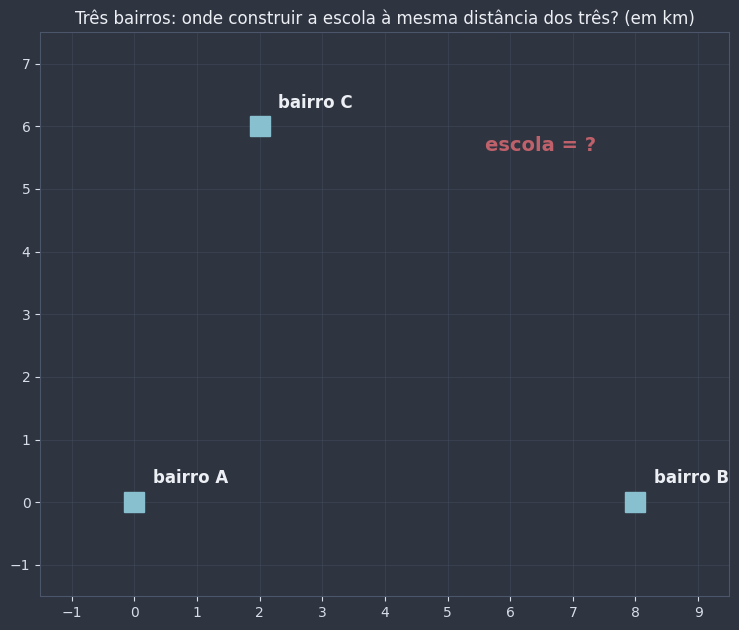

In [19]:
# Figura do Exercício Desafio 5 (apenas desenha; não precisa alterar)
bairros_5 = {"A": np.array([0.0, 0.0]), "B": np.array([8.0, 0.0]), "C": np.array([2.0, 6.0])}
fig, ax = plt.subplots(figsize=(8, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-1.5, -1.5), (9.5, 7.5)], margem=0)
estilizar_eixo(ax)
ax.set_xticks(range(-1, 10))
ax.set_yticks(range(-1, 8))
for nome, ponto in bairros_5.items():
    ax.plot(*ponto, "s", color=COR_PONTO, markersize=14, zorder=5)
    ax.text(ponto[0] + 0.3, ponto[1] + 0.3, f"bairro {nome}", color=NORD_TEXTO, fontsize=12, fontweight="bold")
ax.text(5.6, 5.6, "escola = ?", color=COR_ALERTA, fontsize=14, fontweight="bold")
ax.set_title("Três bairros: onde construir a escola à mesma distância dos três? (em km)",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 5: três bairros de uma cidade ficam nos pontos A = (0, 0), B = (8, 0) e
# C = (2, 6) do mapa (em km). A prefeitura quer construir uma escola à MESMA distância dos três.
# (a) Construa a mediatriz de AB e a mediatriz de AC (cada uma: ponto médio + inclinação).
#     Guarde as inclinações das duas MEDIATRIZES em `inclinacao_AB_ex5` e `inclinacao_AC_ex5`.
# (b) A escola fica no cruzamento das duas mediatrizes (por quê?). Use `cruzamento` para
#     encontrá-la e guarde em `escola_ex5`.
# (c) Calcule as distâncias da escola até A, até B e até C, e guarde numa tupla `distancias_ex5`.
# (d) A escola também está na mediatriz de BC? Responda True ou False em `na_mediatriz_BC_ex5`
#     (sem traçar a terceira mediatriz: use o teorema da seção 4).
A_ex5, B_ex5, C_ex5 = np.array([0.0, 0.0]), np.array([8.0, 0.0]), np.array([2.0, 6.0])

inclinacao_AB_ex5 = ...
inclinacao_AC_ex5 = ...
escola_ex5 = ...
distancias_ex5 = ...
na_mediatriz_BC_ex5 = ...

print(escola_ex5, distancias_ex5, na_mediatriz_BC_ex5)

In [ ]:
# Verificação
assert inclinacao_AB_ex5 is not ... and math.isclose(inclinacao_AB_ex5 % 180, 90), (
    "Tente de novo, revise: AB é horizontal (0°), então a mediatriz de AB tem inclinação 90° (seção 4 - Mediatriz de um segmento)."
)
assert inclinacao_AC_ex5 is not ... and math.isclose((inclinacao_AC_ex5 - direcao_de(A_ex5, C_ex5)) % 180, 90), (
    "Tente de novo, revise: a mediatriz de AC tem a inclinação de AC mais 90° (seção 4 - Mediatriz de um segmento)."
)
assert escola_ex5 is not ... and escola_ex5 is not None and np.allclose(escola_ex5, [4, 2]), (
    "Tente de novo, revise: cruze as duas mediatrizes, cada uma passando pelo ponto médio do seu segmento (seção 4 - Mediatriz de um segmento)."
)
assert distancias_ex5 is not ... and len(distancias_ex5) == 3 and np.allclose(distancias_ex5, math.sqrt(20)), (
    "Tente de novo, revise: as três distâncias devem ser iguais, porque a escola está nas duas mediatrizes (seção 4 - Mediatriz de um segmento)."
)
assert na_mediatriz_BC_ex5 is True, (
    "Tente de novo, revise: se a escola está à mesma distância de B e de C, ela está na mediatriz de BC (seção 4 - Mediatriz de um segmento)."
)
print("Certo!")

Execute a célula abaixo para ver a figura do Exercício Desafio 6.

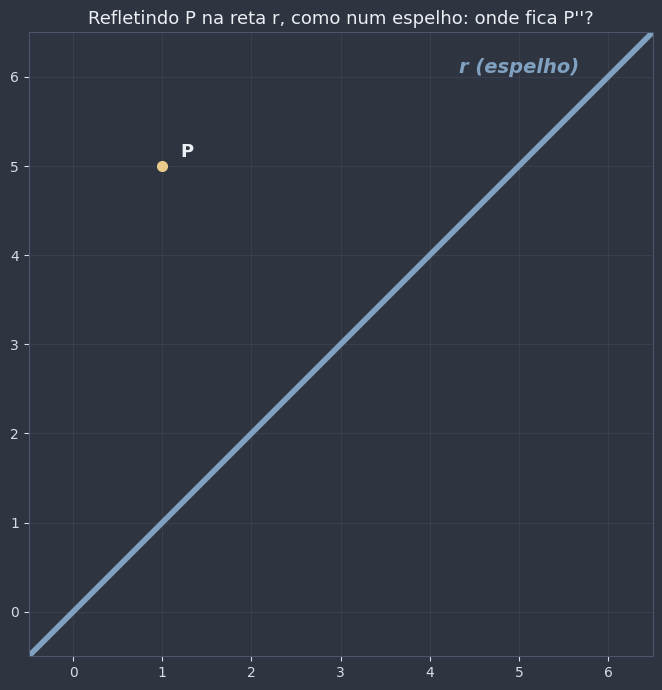

In [20]:
# Figura do Exercício Desafio 6 (apenas desenha; não precisa alterar)
P_6 = np.array([1.0, 5.0])
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.5, -0.5), (6.5, 6.5)], margem=0)
estilizar_eixo(ax)
ax.set_xticks(range(0, 7))
ax.set_yticks(range(0, 7))
desenhar_reta(ax, (0, 0), 45, cor=COR_SECUNDARIA, largura=4, nome="r (espelho)", posicao_nome=(5.0, 6.1))
desenhar_ponto(ax, P_6, "P", deslocamento=(0.2, 0.1))
ax.set_title("Refletindo P na reta r, como num espelho: onde fica P''?", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 6: refletindo um ponto numa reta.
# A reta r passa pela origem O = (0, 0) com inclinação de 45° (é a reta y = x), e P = (1, 5).
# O REFLETIDO de P em relação a r é o ponto P'' do outro lado de r tal que a projeção ortogonal
# P' de P sobre r é o PONTO MÉDIO do segmento PP''. É o que um espelho colocado sobre r mostraria.
# (a) Calcule a projeção ortogonal P' de P sobre r. Guarde em `pe_ex6`.
# (b) Sabendo que P' é o ponto médio de PP'', descubra P''. Guarde em `refletido_ex6`.
#     (Dica: se P' = (P + P'') / 2, isole P''.)
# (c) Calcule a distância de P até r e a distância de P'' até r. Guarde em `dist_P_ex6` e
#     `dist_refletido_ex6`.
# (d) A reta r é a mediatriz do segmento PP''? Responda True ou False em `r_e_mediatriz_ex6`.
#     (Pense: r passa pelo ponto médio de PP''? E é perpendicular a PP''?)
O_ex6, P_ex6, inclinacao_r_ex6 = np.array([0.0, 0.0]), np.array([1.0, 5.0]), 45

pe_ex6 = ...
refletido_ex6 = ...
dist_P_ex6 = ...
dist_refletido_ex6 = ...
r_e_mediatriz_ex6 = ...

print(pe_ex6, refletido_ex6, dist_P_ex6, dist_refletido_ex6, r_e_mediatriz_ex6)

In [ ]:
# Verificação
assert pe_ex6 is not ... and pe_ex6 is not None and np.allclose(pe_ex6, [3, 3]), (
    "Tente de novo, revise: P' é o cruzamento de r com a perpendicular a r por P (seção 3 - Projeção ortogonal e distância de ponto a reta)."
)
assert refletido_ex6 is not ... and np.allclose(refletido_ex6, [5, 1]), (
    "Tente de novo, revise: de P' = (P + P'') / 2 sai P'' = 2·P' − P (seção 4 - Mediatriz de um segmento)."
)
assert dist_P_ex6 is not ... and math.isclose(dist_P_ex6, 2 * math.sqrt(2)), (
    "Tente de novo, revise: a distância de P a r é a medida de PP' (seção 3 - Projeção ortogonal e distância de ponto a reta)."
)
assert dist_refletido_ex6 is not ... and math.isclose(dist_refletido_ex6, 2 * math.sqrt(2)), (
    "Tente de novo, revise: a projeção de P'' sobre r também é P', e a distância é P''P' (seção 3 - Projeção ortogonal e distância de ponto a reta)."
)
assert r_e_mediatriz_ex6 is True, (
    "Tente de novo, revise: r passa pelo ponto médio P' de PP'' e é perpendicular a PP'' (seção 4 - Mediatriz de um segmento)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio, base da mediatriz; distância entre dois pontos)
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (ângulo reto, opostos pelo vértice e suplementares, que mostram que um ângulo reto garante os quatro)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (ao maior ângulo opõe-se o maior lado, usado para provar que a perpendicular é o caminho mais curto)
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (casos LAL e LLL, usados na demonstração da mediatriz como lugar geométrico)
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (postulado das paralelas, ângulos correspondentes e a recíproca, a soma 180° e a ferramenta `cruzamento`)

**Isso será usado em:**
- [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) (mediatrizes e circuncentro; a altura como perpendicular baixada de um vértice; a bissetriz como lugar geométrico)
- 📌 Circunferência e Círculo (a circunferência como lugar geométrico; a distância do centro a uma reta decide se ela é secante, tangente ou exterior)
- 📌 Triângulos Retângulos (projeções ortogonais dos catetos sobre a hipotenusa nas relações métricas)
- 📌 Geometria Analítica (a condição de perpendicularidade com coeficientes angulares e a fórmula da distância de ponto a reta)